In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats
from sklearn import metrics
import sklearn
import matplotlib

In [74]:
Cc = pd.read_excel("C:/Users/Astrocyte/Desktop/Lactate/Lactate fiberphoto/Adra1a eLacco fiberphoto.xlsx", sheet_name='Cont_CNO')

In [74]:
eC = pd.read_excel("C:/Users/Astrocyte/Desktop/Lactate/Lactate fiberphoto/Lactate fiberphoto.xlsx", sheet_name='e-airpuff-CNO')

In [89]:
e01C = pd.read_excel("C:/Users/Astrocyte/Desktop/Lactate/Lactate fiberphoto/Lactate fiberphoto.xlsx", sheet_name='e-airpuff-01CNO')

In [101]:
Cs = pd.read_excel("C:/Users/Astrocyte/Desktop/Lactate/Lactate fiberphoto/Adra1a eLacco fiberphoto.xlsx", sheet_name='Cont_saline')
Ks = pd.read_excel("C:/Users/Astrocyte/Desktop/Lactate/Lactate fiberphoto/Adra1a eLacco fiberphoto.xlsx", sheet_name='KO_saline')

In [11]:
def idx_of_the_nearest(data, value):
  '''
  一番近いインデックスを取得
  '''
  idx = np.argmin(np.abs(np.array(data) - value))

  return idx

In [12]:
def dFF_func(time, iso, green, BC_start_sec, BC_end_sec, BL_start_sec, BL_end_sec, fitting, mouse):
    '''
    dF/Fを算出する関数
    fitting: 1だったら470でfitting, 0だったら405でfitting
    '''
    BC_start = idx_of_the_nearest(time, BC_start_sec)
    BC_end = idx_of_the_nearest(time, BC_end_sec)
    
    BL_start = idx_of_the_nearest(time, BL_start_sec)
    BL_end = idx_of_the_nearest(time, BL_end_sec)
    
    
    add1 = [1 for i in range(len(green))]
    
    fit = np.polyfit(time, iso, 1)
    fittedIso = fit[0] * np.array(time) + fit[1]
    isoBC = iso - fittedIso
    isoBCN = isoBC + add1
    
    fit = np.polyfit(time[BC_start:BC_end], green[BC_start:BC_end], 1)
    fittedGreen = fit[0] * np.array(time) + fit[1]
    
    if fitting == 1:
        greenBC = green - fittedGreen
        greenBCN = greenBC + add1
        
    else:
        greenBC = green - fittedIso
        greenBCN = greenBC + add1
        
    BL_mean = np.mean(greenBCN[BL_start:BL_end] / isoBCN[BL_start:BL_end])
    dFF = greenBCN / isoBCN - BL_mean
    
    fig_func(time, iso, green, fittedIso, fittedGreen, isoBCN, greenBCN, dFF, BC_start, BC_end, BL_start, BL_end, fitting, mouse)
    
    return dFF

In [183]:
def fig_func(time, iso, green, fittedIso, fittedGeen, isoBCN, greenBCN, dFF, BC_start, BC_end, BL_start, BL_end, fitting, mouse):
    
    plt.figure(figsize=(50, 2))
    plt.subplots_adjust(wspace=0.1, hspace=0.1)
    
    #plt.subplot(1, 3, 1)
    #plt.plot(time, iso, color="gray")
    #plt.plot(time, green, color="black")
    
    if fitting == 1:
        plt.plot(time[BC_start:BC_end], green[BC_start:BC_end], color="red")
        plt.plot(time, fittedIso, color="blue")
        
    if fitting == 1:
        plt.plot(time, fittedGeen, color="blue")
    else:
        plt.plot(time, fittedIso, color="blue")
        

    #plt.subplot(1, 3, 2)
    #plt.plot(time, isoBCN, color="gray")
    #plt.plot(time, greenBCN, color="black")

    plt.subplot(1, 3, 3)
    plt.plot(time, dFF, color="green")
    plt.plot(time[BL_start:BL_end], dFF[BL_start:BL_end], color='red')
    
    plt.title('{}'.format(mouse))

In [14]:
time_ = [float(_) for _ in np.array(Cc.filter(like=('Time'), axis=1))][10:-9]

In [60]:
Cont1_CNO = np.array(Cc.filter(['Cont1_iso', 'Cont1_green']))[10:-9]
Cont2_CNO = np.array(Cc.filter(['Cont2_iso', 'Cont2_green']))[10:-9]
Cont3_CNO = np.array(Cc.filter(['Cont3_iso', 'Cont3_green']))[10:-9]
Cont4_CNO = np.array(Cc.filter(['Cont4_iso', 'Cont4_green']))[10:-9]
Cont5_CNO = np.array(Cc.filter(['Cont5_iso', 'Cont5_green']))[10:-9]
Cont6_CNO = np.array(Cc.filter(['Cont6_iso', 'Cont6_green']))[10:-9]
Cont7_CNO = np.array(Cc.filter(['Cont7_iso', 'Cont7_green']))[10:-9]
Cont8_CNO = np.array(Cc.filter(['Cont8_iso', 'Cont8_green']))[10:-9]

In [75]:
hM3Dq1_CNO = np.array(eC.filter(['e-lacco1_CNO_iso', 'e-lacco1_CNO_green']))[10:-9]
hM3Dq2_CNO = np.array(eC.filter(['e-lacco2_CNO_iso', 'e-lacco2_CNO_green']))[10:-9]
hM3Dq3_CNO = np.array(eC.filter(['e-lacco3_CNO_iso', 'e-lacco3_CNO_green']))[10:-9]
hM3Dq4_CNO = np.array(eC.filter(['e-lacco4_CNO_iso', 'e-lacco4_CNO_green']))[10:-9]
hM3Dq5_CNO = np.array(eC.filter(['e-lacco5_CNO_iso', 'e-lacco5_CNO_green']))[10:-9]
hM3Dq6_CNO = np.array(eC.filter(['e-lacco6_CNO_iso', 'e-lacco6_CNO_green']))[10:-9]
hM3Dq7_CNO = np.array(eC.filter(['e-lacco7_CNO_iso', 'e-lacco7_CNO_green']))[10:-9]

In [93]:
hM3Dq1_01CNO = np.array(e01C.filter(['e-lacco1_01CNO_iso', 'e-lacco1_01CNO_green']))[10:-9]
hM3Dq2_01CNO = np.array(e01C.filter(['e-lacco2_01CNO_iso', 'e-lacco2_01CNO_green']))[10:-9]
hM3Dq3_01CNO = np.array(e01C.filter(['e-lacco3_01CNO_iso', 'e-lacco3_01CNO_green']))[10:-9]
hM3Dq4_01CNO = np.array(e01C.filter(['e-lacco4_01CNO_iso', 'e-lacco4_01CNO_green']))[10:-9]
hM3Dq5_01CNO = np.array(e01C.filter(['e-lacco5_01CNO_iso', 'e-lacco5_01CNO_green']))[10:-9]
hM3Dq6_01CNO = np.array(e01C.filter(['e-lacco6_01CNO_iso', 'e-lacco6_01CNO_green']))[10:-9]
hM3Dq7_01CNO = np.array(e01C.filter(['e-lacco7_01CNO_iso', 'e-lacco7_01CNO_green']))[10:-9]

In [102]:
Cont1_saline = np.array(Cs.filter(['Cont1_iso', 'Cont1_green']))[10:-9]
Cont2_saline = np.array(Cs.filter(['Cont2_iso', 'Cont2_green']))[10:-9]
Cont3_saline = np.array(Cs.filter(['Cont3_iso', 'Cont3_green']))[10:-9]
Cont4_saline = np.array(Cs.filter(['Cont4_iso', 'Cont4_green']))[10:-9]
Cont5_saline = np.array(Cs.filter(['Cont5_iso', 'Cont5_green']))[10:-9]
Cont6_saline = np.array(Cs.filter(['Cont6_iso', 'Cont6_green']))[10:-9]
Cont7_saline = np.array(Cs.filter(['Cont7_iso', 'Cont7_green']))[10:-9]
Cont8_saline = np.array(Cs.filter(['Cont8_iso', 'Cont8_green']))[10:-9]

In [132]:
KO1_saline = np.array(Ks.filter(['KO1_iso', 'KO1_green']))[10:-9]
KO2_saline = np.array(Ks.filter(['KO2_iso', 'KO2_green']))[10:-9]
KO3_saline = np.array(Ks.filter(['KO3_iso', 'KO3_green']))[10:-9]
KO4_saline = np.array(Ks.filter(['KO4_iso', 'KO4_green']))[10:-9]
KO5_saline = np.array(Ks.filter(['KO5_iso', 'KO5_green']))[10:-9]
KO6_saline = np.array(Ks.filter(['KO6_iso', 'KO6_green']))[10:-9]
KO7_saline = np.array(Ks.filter(['KO7_iso', 'KO7_green']))[10:-9]
KO8_saline = np.array(Ks.filter(['KO8_iso', 'KO8_green']))[10:-9]
KO9_saline = np.array(Ks.filter(['KO9_iso', 'KO9_green']))[10:-9]

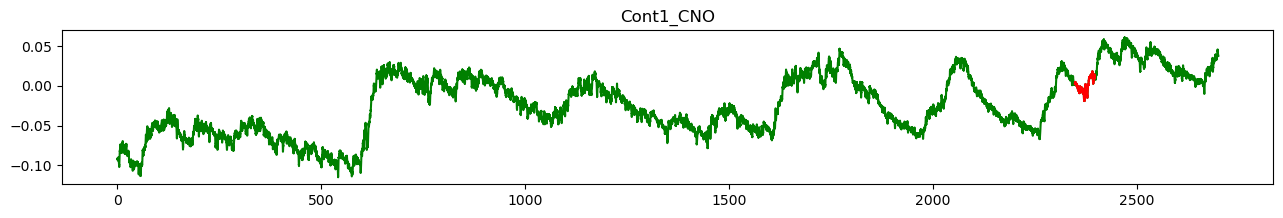

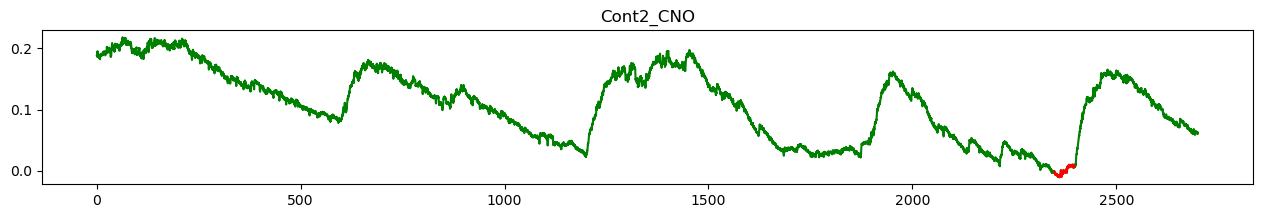

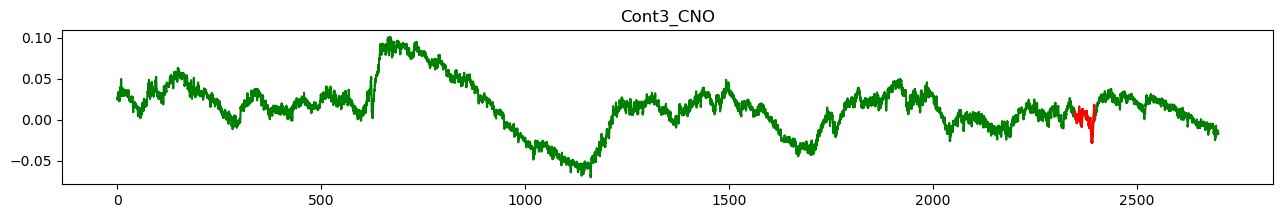

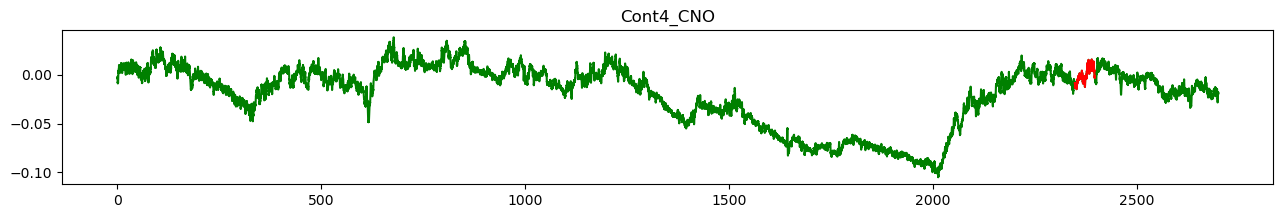

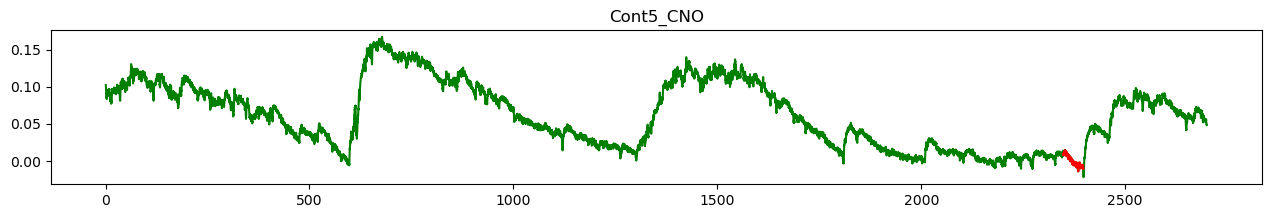

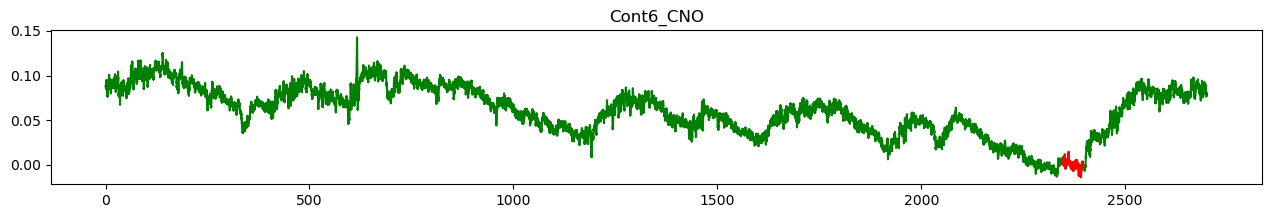

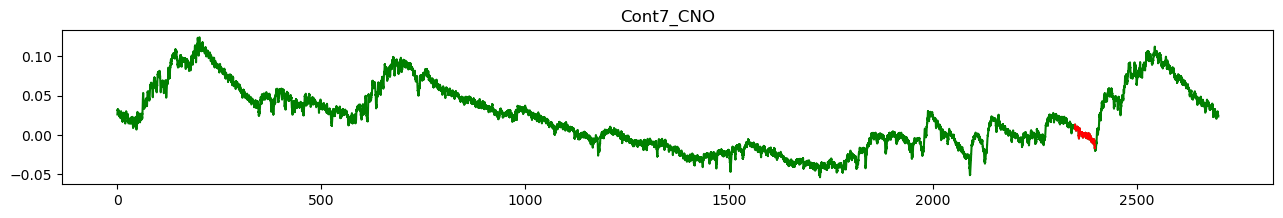

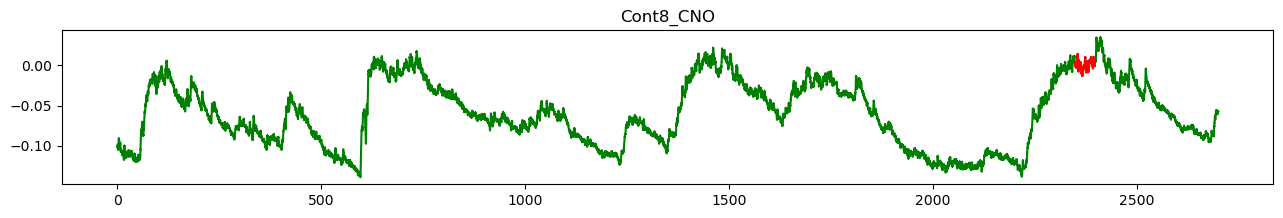

In [184]:
Cont1_CNO_dFF = dFF_func(time_, Cont1_CNO[:,0], Cont1_CNO[:,1], 0, 2700, 2348, 2397, 0, "Cont1_CNO")
Cont2_CNO_dFF = dFF_func(time_, Cont2_CNO[:,0], Cont2_CNO[:,1], 0, 2700, 2348, 2397, 0, "Cont2_CNO")
Cont3_CNO_dFF = dFF_func(time_, Cont3_CNO[:,0], Cont3_CNO[:,1], 0, 2700, 2348, 2397, 0, "Cont3_CNO")
Cont4_CNO_dFF = dFF_func(time_, Cont4_CNO[:,0], Cont4_CNO[:,1], 0, 2700, 2348, 2397, 0, "Cont4_CNO")
Cont5_CNO_dFF = dFF_func(time_, Cont5_CNO[:,0], Cont5_CNO[:,1], 0, 2700, 2348, 2397, 0, "Cont5_CNO")
Cont6_CNO_dFF = dFF_func(time_, Cont6_CNO[:,0], Cont6_CNO[:,1], 0, 2700, 2348, 2397, 0, "Cont6_CNO")
Cont7_CNO_dFF = dFF_func(time_, Cont7_CNO[:,0], Cont7_CNO[:,1], 0, 2700, 2348, 2397, 0, "Cont7_CNO")
Cont8_CNO_dFF = dFF_func(time_, Cont8_CNO[:,0], Cont8_CNO[:,1], 0, 2700, 2348, 2397, 0, "Cont8_CNO")

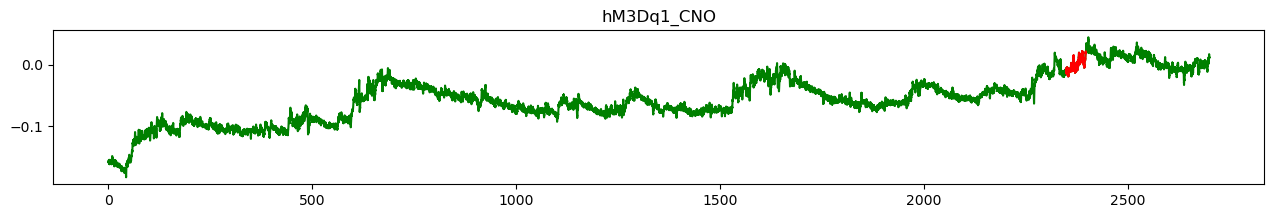

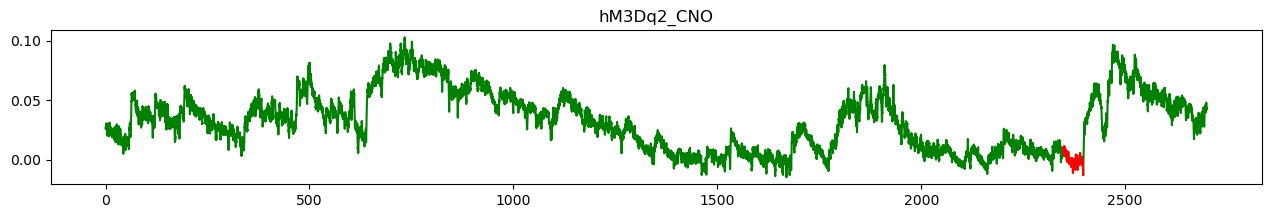

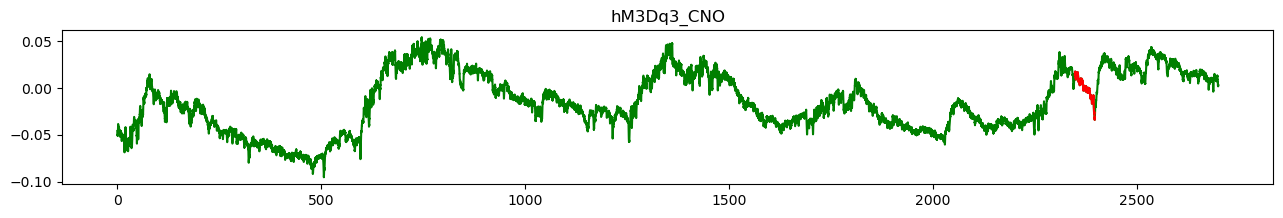

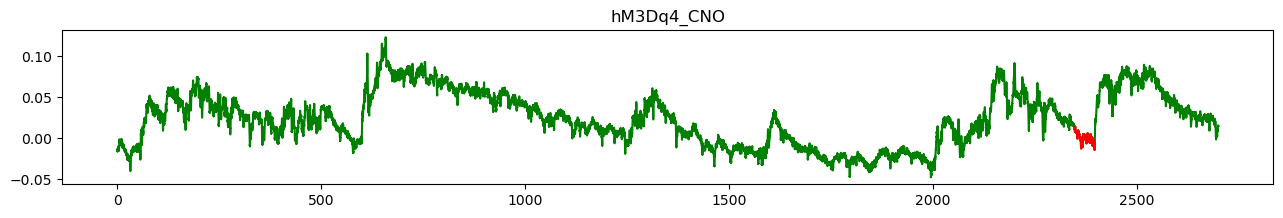

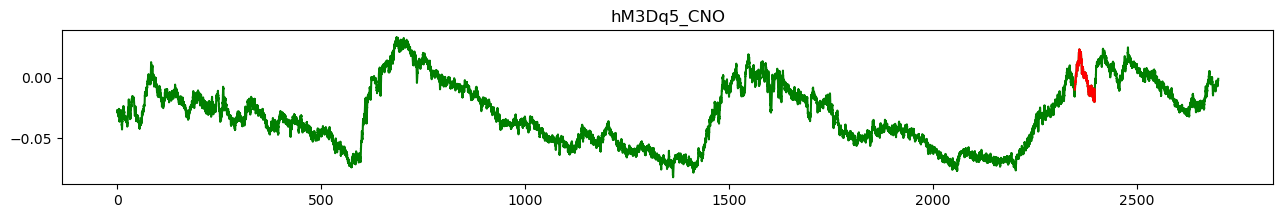

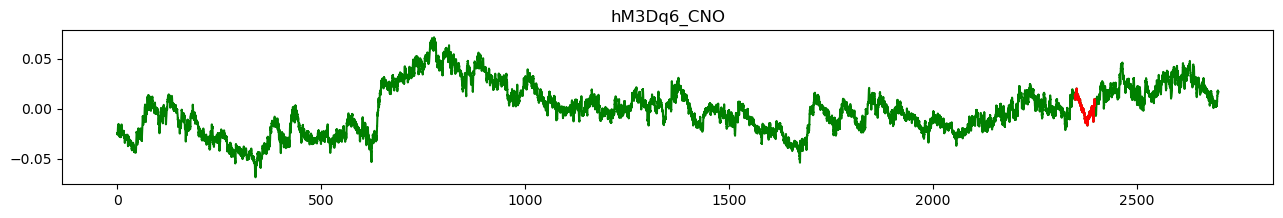

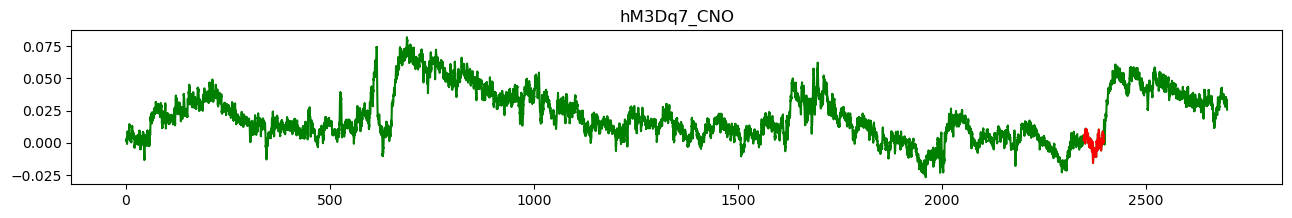

In [185]:
hM3Dq1_CNO_dFF = dFF_func(time_, hM3Dq1_CNO[:,0], hM3Dq1_CNO[:,1], 0, 2640, 2348, 2397, 0, "hM3Dq1_CNO")
hM3Dq2_CNO_dFF = dFF_func(time_, hM3Dq2_CNO[:,0], hM3Dq2_CNO[:,1], 0, 2700, 2348, 2397, 0, "hM3Dq2_CNO")
hM3Dq3_CNO_dFF = dFF_func(time_, hM3Dq3_CNO[:,0], hM3Dq3_CNO[:,1], 0, 2700, 2348, 2397, 0, "hM3Dq3_CNO")
hM3Dq4_CNO_dFF = dFF_func(time_, hM3Dq4_CNO[:,0], hM3Dq4_CNO[:,1], 0, 2700, 2348, 2397, 0, "hM3Dq4_CNO")
hM3Dq5_CNO_dFF = dFF_func(time_, hM3Dq5_CNO[:,0], hM3Dq5_CNO[:,1], 0, 2700, 2348, 2397, 0, "hM3Dq5_CNO")
hM3Dq6_CNO_dFF = dFF_func(time_, hM3Dq6_CNO[:,0], hM3Dq6_CNO[:,1], 0, 2700, 2348, 2397, 0, "hM3Dq6_CNO")
hM3Dq7_CNO_dFF = dFF_func(time_, hM3Dq7_CNO[:,0], hM3Dq7_CNO[:,1], 0, 2700, 2348, 2397, 0, "hM3Dq7_CNO")

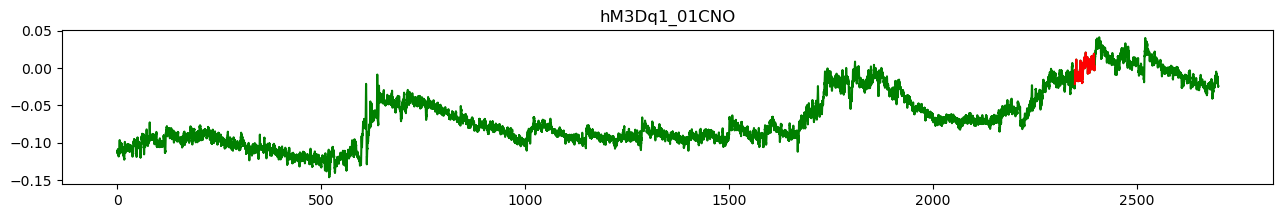

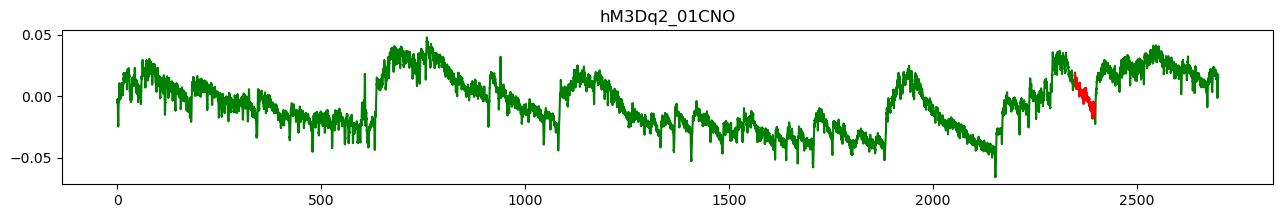

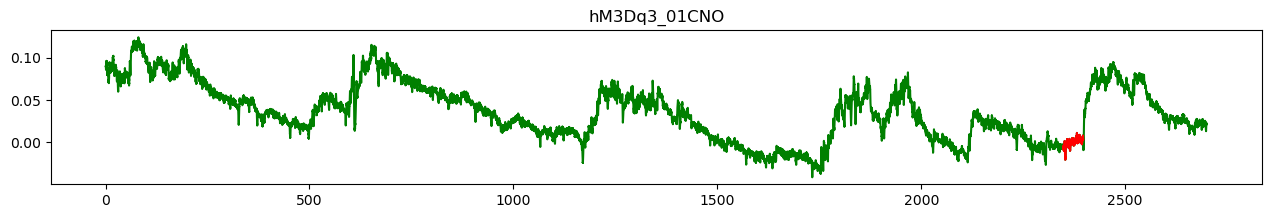

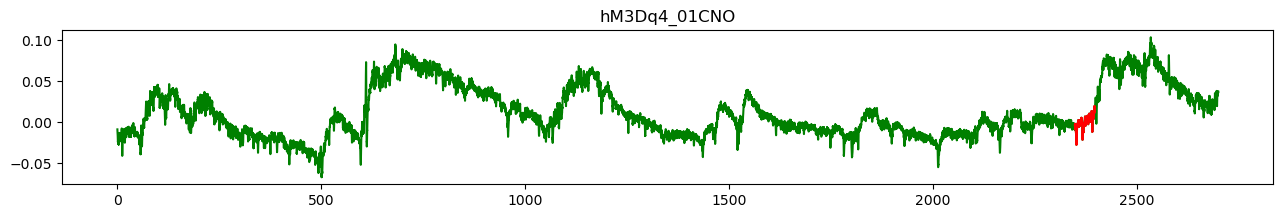

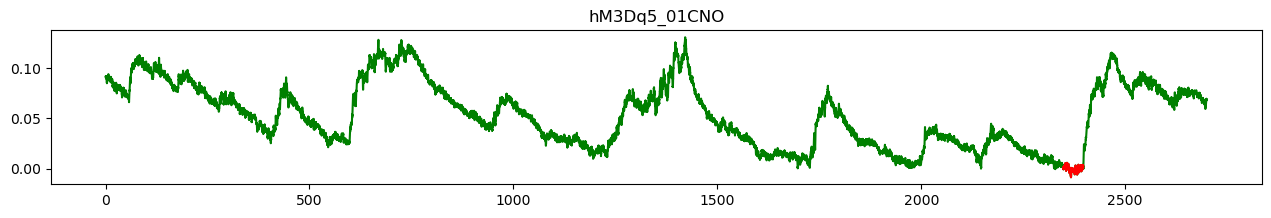

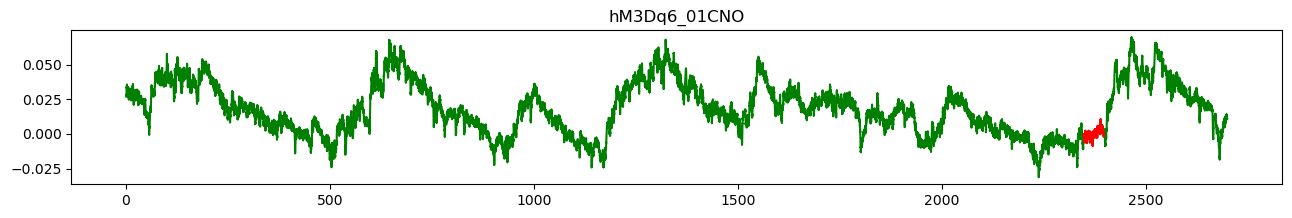

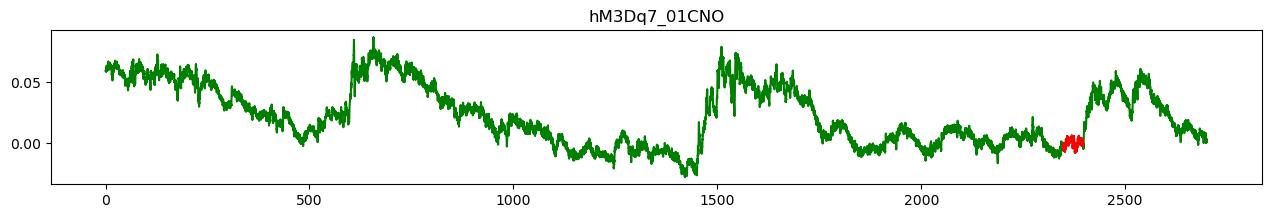

In [186]:
hM3Dq1_01CNO_dFF = dFF_func(time_, hM3Dq1_01CNO[:,0], hM3Dq1_01CNO[:,1], 0, 2700, 2348, 2397, 0, "hM3Dq1_01CNO")
hM3Dq2_01CNO_dFF = dFF_func(time_, hM3Dq2_01CNO[:,0], hM3Dq2_01CNO[:,1], 0, 2700, 2348, 2397, 0, "hM3Dq2_01CNO")
hM3Dq3_01CNO_dFF = dFF_func(time_, hM3Dq3_01CNO[:,0], hM3Dq3_01CNO[:,1], 0, 2700, 2348, 2397, 0, "hM3Dq3_01CNO")
hM3Dq4_01CNO_dFF = dFF_func(time_, hM3Dq4_01CNO[:,0], hM3Dq4_01CNO[:,1], 0, 2700, 2348, 2397, 0, "hM3Dq4_01CNO")
hM3Dq5_01CNO_dFF = dFF_func(time_, hM3Dq5_01CNO[:,0], hM3Dq5_01CNO[:,1], 0, 2700, 2348, 2397, 0, "hM3Dq5_01CNO")
hM3Dq6_01CNO_dFF = dFF_func(time_, hM3Dq6_01CNO[:,0], hM3Dq6_01CNO[:,1], 0, 2700, 2348, 2397, 0, "hM3Dq6_01CNO")
hM3Dq7_01CNO_dFF = dFF_func(time_, hM3Dq7_01CNO[:,0], hM3Dq7_01CNO[:,1], 0, 2700, 2348, 2397, 0, "hM3Dq7_01CNO")

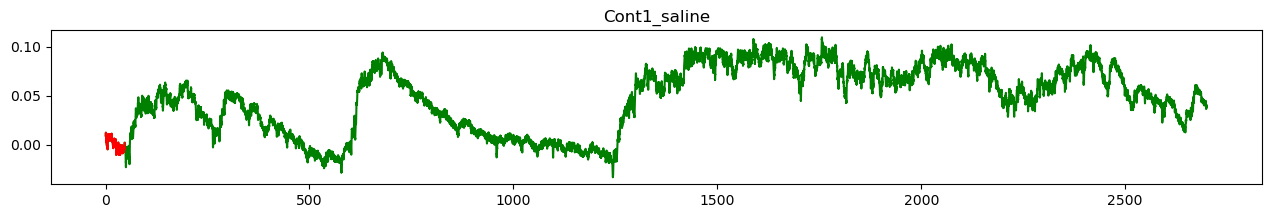

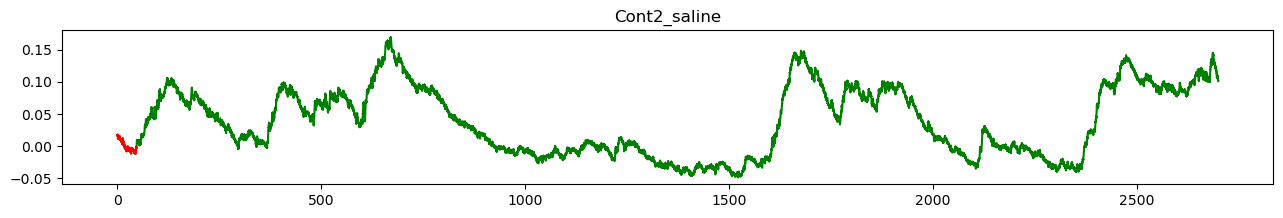

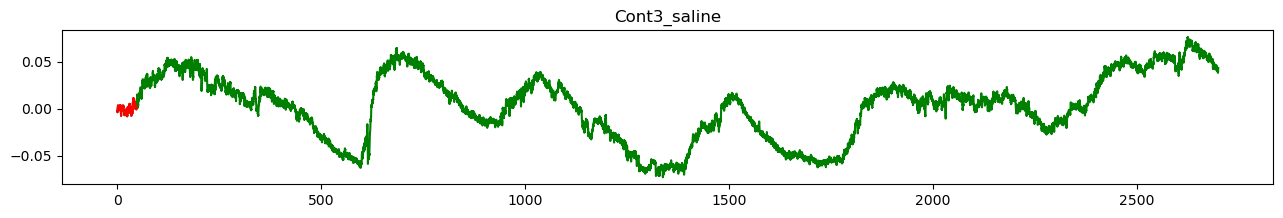

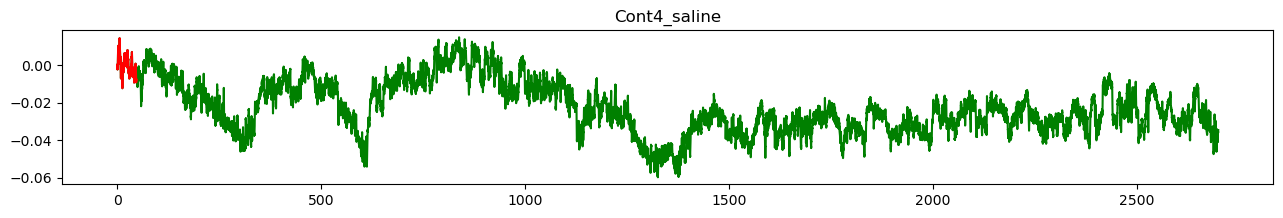

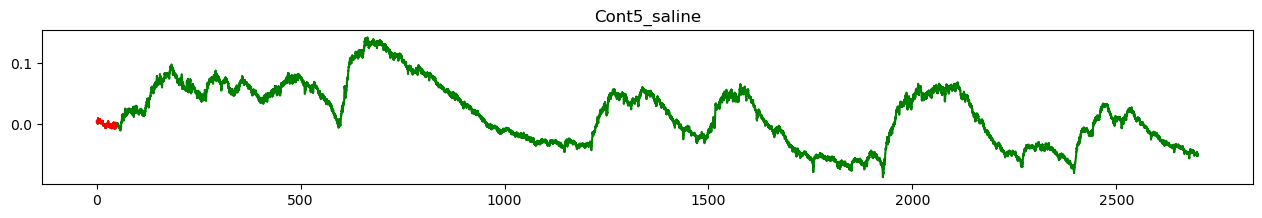

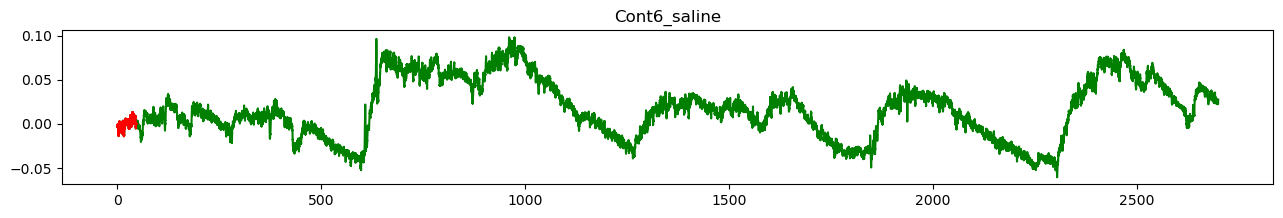

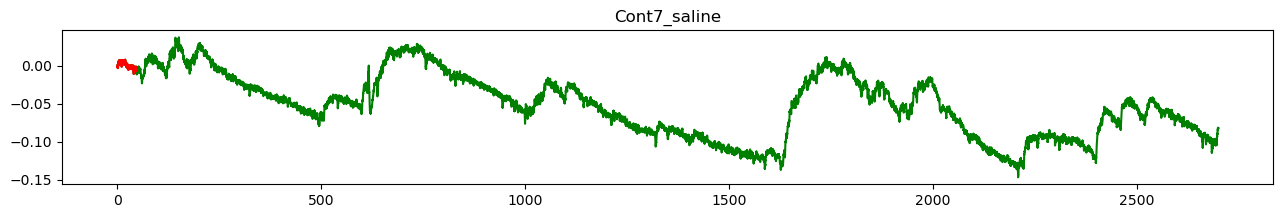

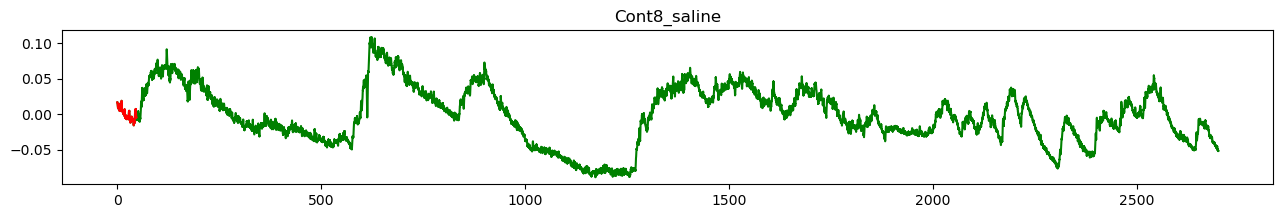

In [187]:
Cont1_saline_dFF = dFF_func(time_, Cont1_saline[:,0], Cont1_saline[:,1], 0, 2700, 0, 47, 0, "Cont1_saline")
Cont2_saline_dFF = dFF_func(time_, Cont2_saline[:,0], Cont2_saline[:,1], 0, 2700, 0, 47, 0, "Cont2_saline")
Cont3_saline_dFF = dFF_func(time_, Cont3_saline[:,0], Cont3_saline[:,1], 0, 2700, 0, 47, 0, "Cont3_saline")
Cont4_saline_dFF = dFF_func(time_, Cont4_saline[:,0], Cont4_saline[:,1], 0, 2700, 0, 47, 0, "Cont4_saline")
Cont5_saline_dFF = dFF_func(time_, Cont5_saline[:,0], Cont5_saline[:,1], 0, 2700, 0, 47, 0, "Cont5_saline")
Cont6_saline_dFF = dFF_func(time_, Cont6_saline[:,0], Cont6_saline[:,1], 0, 2700, 0, 47, 0, "Cont6_saline")
Cont7_saline_dFF = dFF_func(time_, Cont7_saline[:,0], Cont7_saline[:,1], 0, 2700, 0, 47, 0, "Cont7_saline")
Cont8_saline_dFF = dFF_func(time_, Cont8_saline[:,0], Cont8_saline[:,1], 0, 2700, 0, 47, 0, "Cont8_saline")

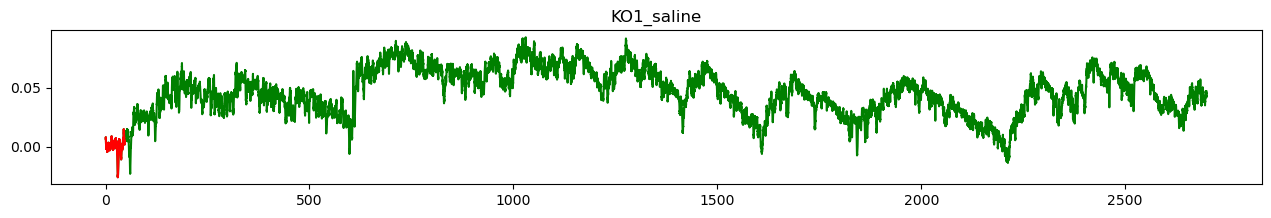

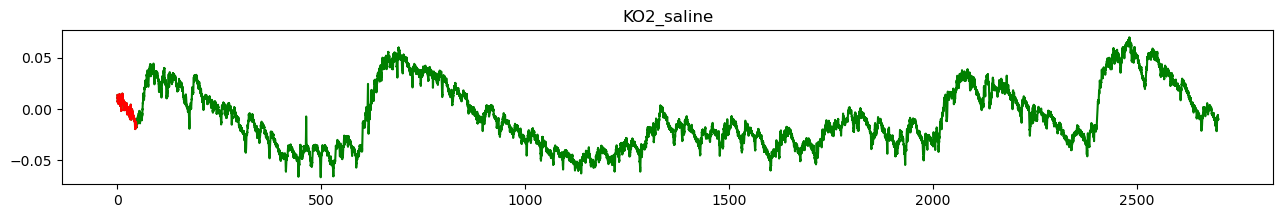

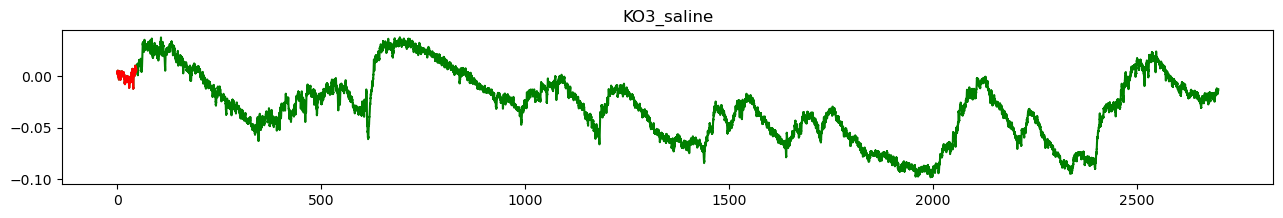

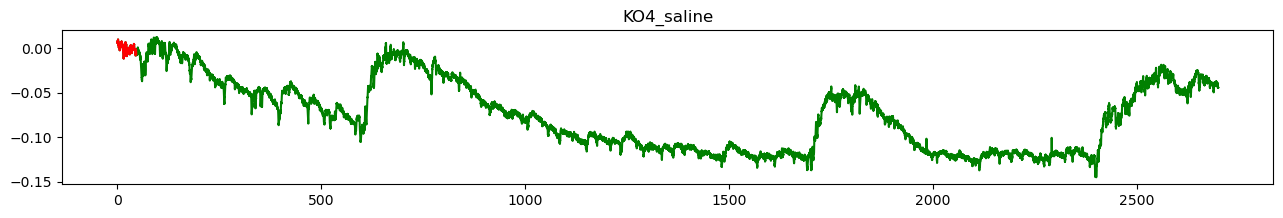

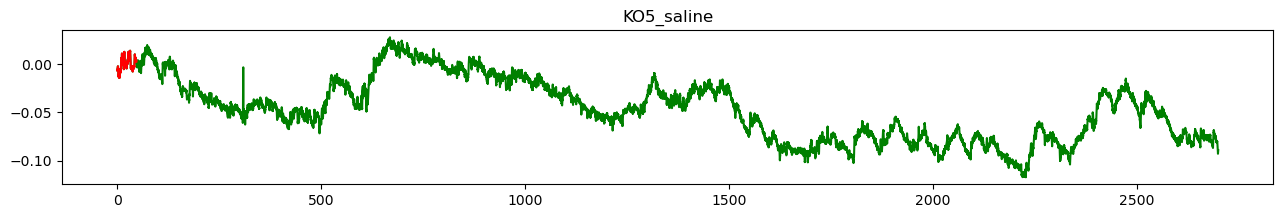

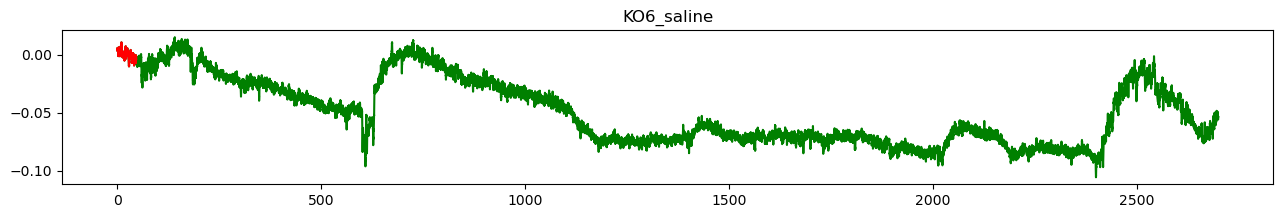

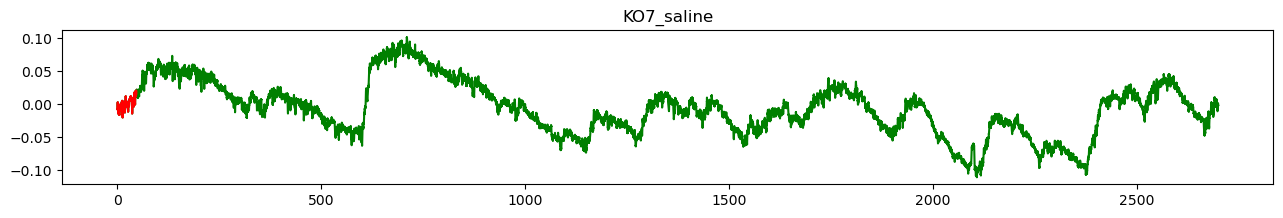

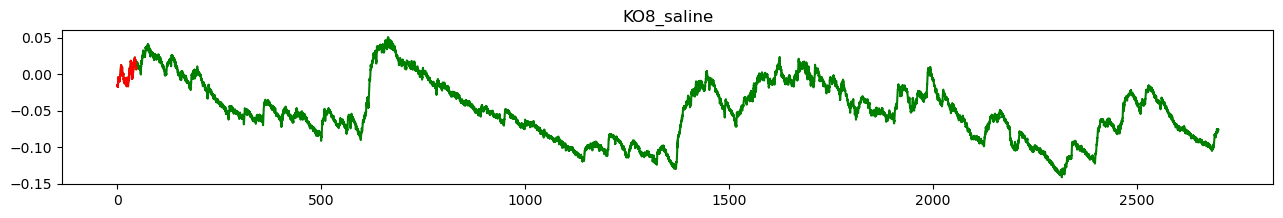

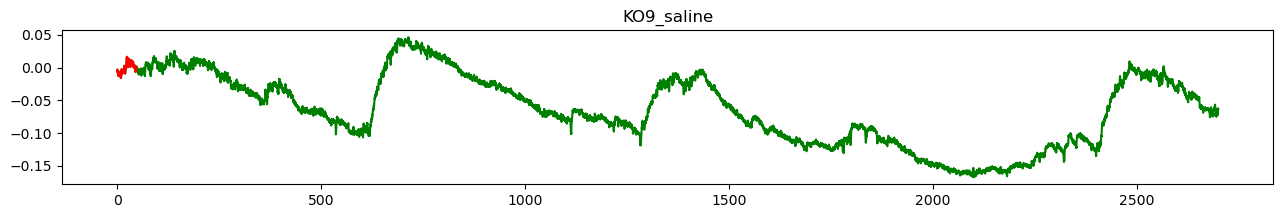

In [188]:
KO1_saline_dFF = dFF_func(time_, KO1_saline[:,0], KO1_saline[:,1], 0, 2700, 0, 47, 0, "KO1_saline")
KO2_saline_dFF = dFF_func(time_, KO2_saline[:,0], KO2_saline[:,1], 0, 2700, 0, 47, 0, "KO2_saline")
KO3_saline_dFF = dFF_func(time_, KO3_saline[:,0], KO3_saline[:,1], 0, 2700, 0, 47, 0, "KO3_saline")
KO4_saline_dFF = dFF_func(time_, KO4_saline[:,0], KO4_saline[:,1], 0, 2700, 0, 47, 0, "KO4_saline")
KO5_saline_dFF = dFF_func(time_, KO5_saline[:,0], KO5_saline[:,1], 0, 2700, 0, 47, 0, "KO5_saline")
KO6_saline_dFF = dFF_func(time_, KO6_saline[:,0], KO6_saline[:,1], 0, 2700, 0, 47, 0, "KO6_saline")
KO7_saline_dFF = dFF_func(time_, KO7_saline[:,0], KO7_saline[:,1], 0, 2700, 0, 47, 0, "KO7_saline")
KO8_saline_dFF = dFF_func(time_, KO8_saline[:,0], KO8_saline[:,1], 0, 2700, 0, 47, 0, "KO8_saline")
KO9_saline_dFF = dFF_func(time_, KO9_saline[:,0], KO9_saline[:,1], 0, 2700, 0, 47, 0, "KO9_saline")

In [142]:
Cont_CNO_dFF = pd.DataFrame([Cont1_CNO_dFF, Cont2_CNO_dFF, Cont3_CNO_dFF, Cont4_CNO_dFF, Cont5_CNO_dFF, Cont6_CNO_dFF, Cont7_CNO_dFF, Cont8_CNO_dFF]).T

Cont_CNO_dFF.columns = ["Cont1_CNO", "Cont2_CNO", "Cont3_CNO", "Cont4_CNO", "Cont5_CNO", "Cont6_CNO", "Cont7_CNO", "Cont8_CNO"]
Cont_CNO_dFF.index = time_

In [151]:
hM3Dq_CNO_dFF = pd.DataFrame([hM3Dq1_CNO_dFF, hM3Dq2_CNO_dFF, hM3Dq3_CNO_dFF, hM3Dq4_CNO_dFF, hM3Dq5_CNO_dFF, hM3Dq6_CNO_dFF, hM3Dq7_CNO_dFF]).T

hM3Dq_CNO_dFF.columns = ["hM3Dq1_CNO", "hM3Dq2_CNO", "hM3Dq3_CNO", "hM3Dq4_CNO", "hM3Dq5_CNO", "hM3Dq6_CNO", "hM3Dq7_CNO"]
hM3Dq_CNO_dFF.index = time_

In [158]:
hM3Dq_01CNO_dFF = pd.DataFrame([hM3Dq1_01CNO_dFF, hM3Dq2_01CNO_dFF, hM3Dq3_01CNO_dFF, hM3Dq4_01CNO_dFF, hM3Dq5_01CNO_dFF, hM3Dq6_01CNO_dFF, hM3Dq7_01CNO_dFF]).T

hM3Dq_01CNO_dFF.columns = ["hM3Dq1_01CNO", "hM3Dq2_01CNO", "hM3Dq3_01CNO", "hM3Dq4_01CNO", "hM3Dq5_01CNO", "hM3Dq6_01CNO", "hM3Dq7_01CNO"]
hM3Dq_01CNO_dFF.index = time_

In [166]:
Cont_saline_dFF = pd.DataFrame([Cont1_saline_dFF, Cont2_saline_dFF, Cont3_saline_dFF, Cont4_saline_dFF, Cont5_saline_dFF, Cont6_saline_dFF, Cont7_saline_dFF, Cont8_saline_dFF]).T

Cont_saline_dFF.columns = ["Cont1_saline", "Cont2_saline", "Cont3_saline", "Cont4_saline", "Cont5_saline", "Cont6_saline", "Cont7_saline", "Cont8_saline"]
Cont_saline_dFF.index = time_

In [167]:
KO_saline_dFF = pd.DataFrame([KO1_saline_dFF, KO2_saline_dFF, KO3_saline_dFF, KO4_saline_dFF, KO5_saline_dFF, KO6_saline_dFF, KO7_saline_dFF, KO8_saline_dFF, KO9_saline_dFF]).T

KO_saline_dFF.columns = ["KO1_saline", "KO2_saline", "KO3_saline", "KO4_saline", "KO5_saline", "KO6_saline", "KO7_saline", "KO8_saline", "KO9_saline"]
KO_saline_dFF.index = time_

# hM3Dq analysis peak

In [143]:
puff1_start_post, puff1_end_post = idx_of_the_nearest(time_, 2388), idx_of_the_nearest(time_, 2457)+1
puff2_start_post, puff2_end_post = idx_of_the_nearest(time_, 2458), idx_of_the_nearest(time_, 2517)+1
puff3_start_post, puff3_end_post = idx_of_the_nearest(time_, 2518), idx_of_the_nearest(time_, 2577)+1

### NonD Control CNO

In [144]:
Cont_CNO_puff1_peakInd_pre = Cont_CNO_dFF.iloc[puff1_start_post:puff1_end_post,:].idxmax()
Cont_CNO_puff2_peakInd_pre = Cont_CNO_dFF.iloc[puff2_start_post:puff2_end_post,:].idxmax()
Cont_CNO_puff3_peakInd_pre = Cont_CNO_dFF.iloc[puff3_start_post:puff3_end_post,:].idxmax()

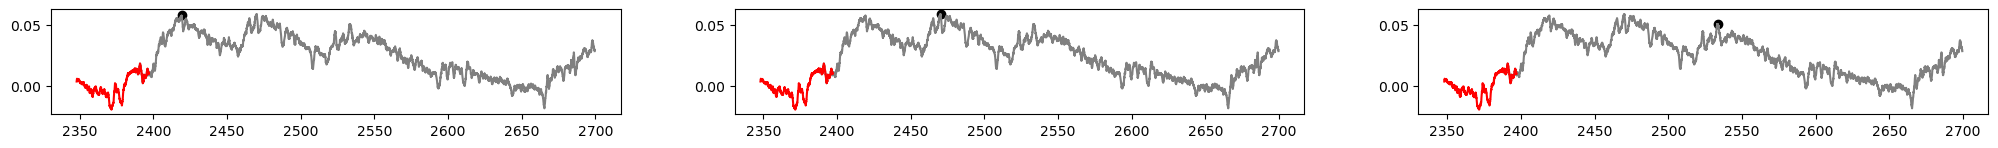

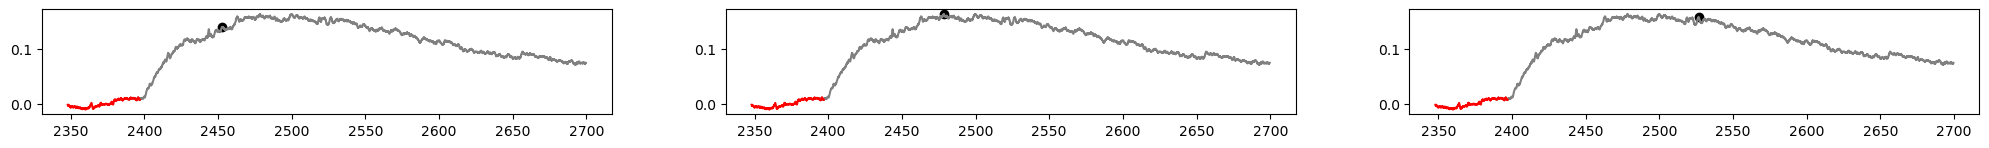

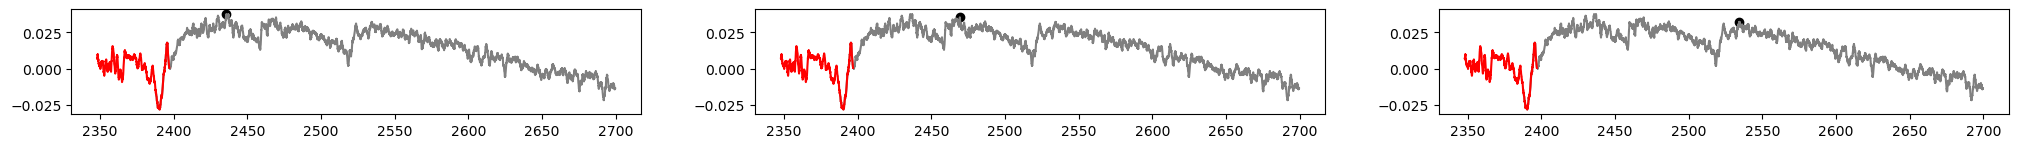

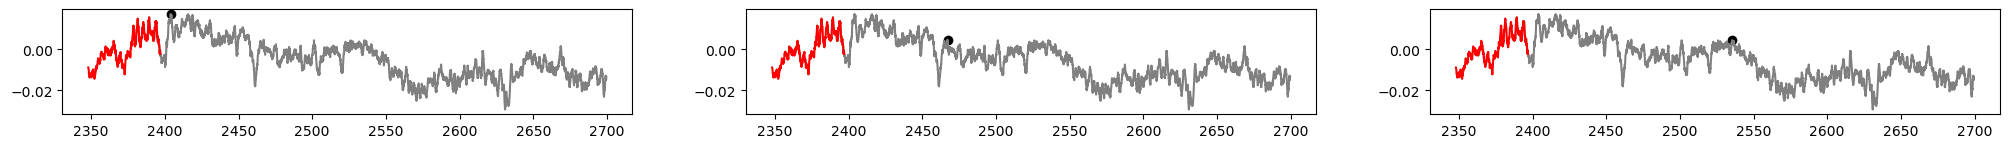

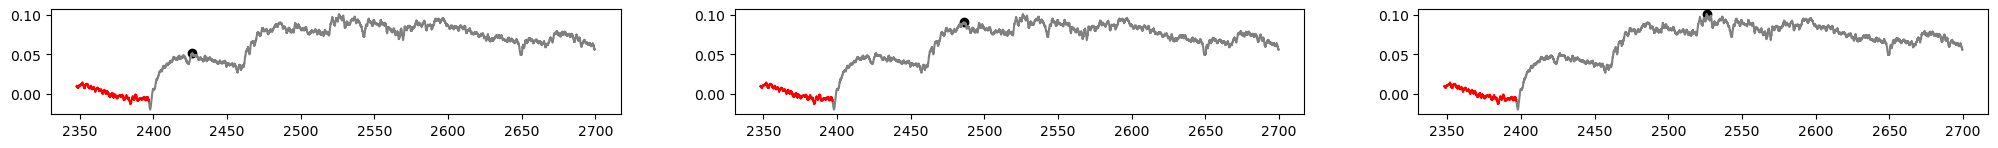

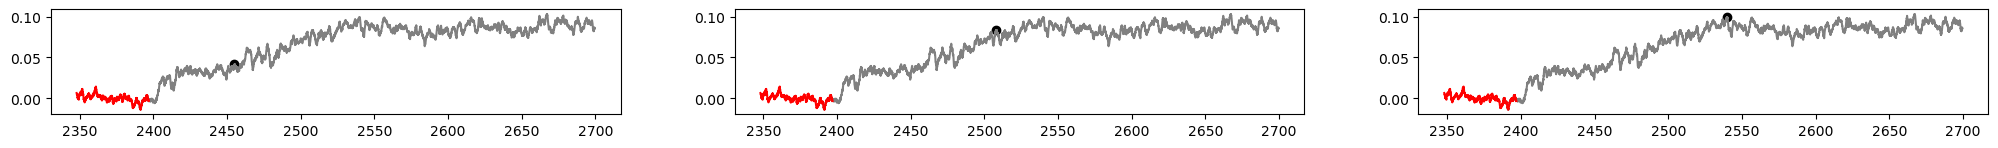

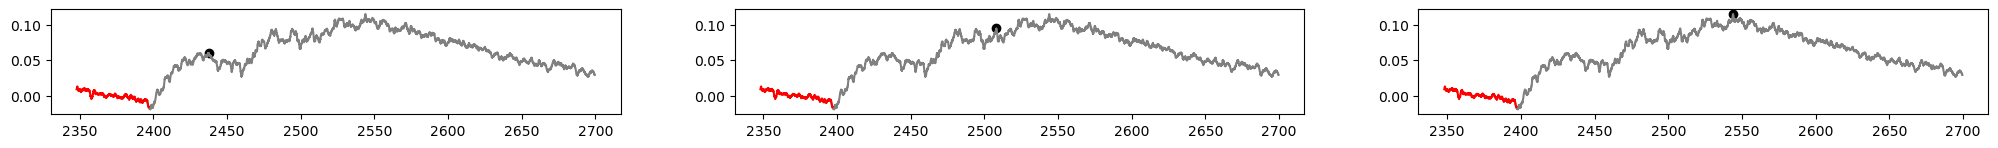

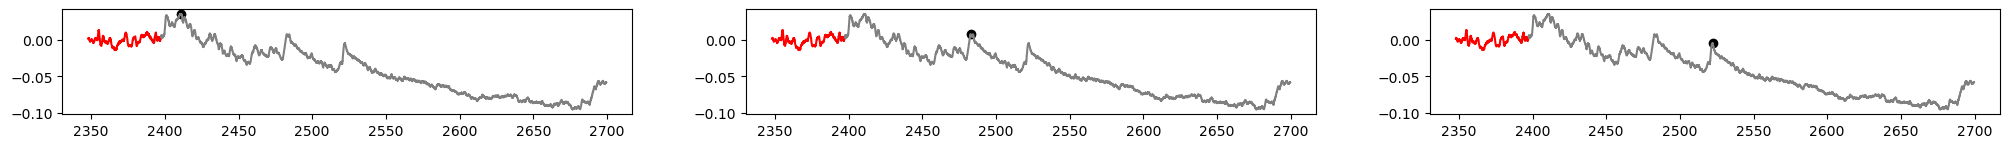

In [145]:
for i,c in enumerate(Cont_CNO_dFF.columns):
    fig = plt.figure(figsize=(25, 3))
    ax1 = fig.add_subplot(2,3,1)
    ax2 = fig.add_subplot(2,3,2)
    ax3 = fig.add_subplot(2,3,3)
    

    ax1.plot(Cont_CNO_dFF.iloc[puff1_start_post:,i].index, Cont_CNO_dFF.iloc[puff1_start_post:,i], color="gray")
    ax1.plot(Cont_CNO_dFF.index[idx_of_the_nearest(time_, 2348):idx_of_the_nearest(time_, 2397)], Cont_CNO_dFF.iloc[idx_of_the_nearest(time_, 2348):idx_of_the_nearest(time_, 2397), i], color="red")
    ax1.scatter(Cont_CNO_puff1_peakInd_pre[i], Cont_CNO_dFF.loc[Cont_CNO_puff1_peakInd_pre[i],c], color="black")
    #plt.ylim(-0.05, 0.15)

    ax2.plot(Cont_CNO_dFF.iloc[puff1_start_post:,i].index, Cont_CNO_dFF.iloc[puff1_start_post:,i], color="gray")
    ax2.plot(Cont_CNO_dFF.index[idx_of_the_nearest(time_, 2348):idx_of_the_nearest(time_, 2397)], Cont_CNO_dFF.iloc[idx_of_the_nearest(time_, 2348):idx_of_the_nearest(time_, 2397), i], color="red")
    ax2.scatter(Cont_CNO_puff2_peakInd_pre[i], Cont_CNO_dFF.loc[Cont_CNO_puff2_peakInd_pre[i],c], color="black")
    #plt.ylim(-0.05, 0.15)
    
    ax3.plot(Cont_CNO_dFF.iloc[puff1_start_post:,i].index, Cont_CNO_dFF.iloc[puff1_start_post:,i], color="gray")
    ax3.plot(Cont_CNO_dFF.index[idx_of_the_nearest(time_, 2348):idx_of_the_nearest(time_, 2397)], Cont_CNO_dFF.iloc[idx_of_the_nearest(time_, 2348):idx_of_the_nearest(time_, 2397), i], color="red")
    ax3.scatter(Cont_CNO_puff3_peakInd_pre[i], Cont_CNO_dFF.loc[Cont_CNO_puff3_peakInd_pre[i],c], color="black")
    #plt.ylim(-0.05, 0.15)

In [146]:
def peak_func(dFF_data, peakInd):
    peak_dict = {}
    
    for i, mouse in enumerate(dFF_data.columns):
        peak_dict["{}".format(mouse)] = dFF_data.loc[peakInd[i],mouse]
            
    return peak_dict

In [147]:
peak_func(Cont_CNO_dFF, Cont_CNO_puff1_peakInd_pre)

{'Cont1_CNO': 0.05806514059840462,
 'Cont2_CNO': 0.1404819430767278,
 'Cont3_CNO': 0.037677989076751794,
 'Cont4_CNO': 0.01728986329626081,
 'Cont5_CNO': 0.05119901530342297,
 'Cont6_CNO': 0.041689976273378004,
 'Cont7_CNO': 0.06030581131455337,
 'Cont8_CNO': 0.03624175996826828}

In [148]:
peak_func(Cont_CNO_dFF, Cont_CNO_puff2_peakInd_pre)

{'Cont1_CNO': 0.05924002267351802,
 'Cont2_CNO': 0.16417350440931322,
 'Cont3_CNO': 0.03540525776442749,
 'Cont4_CNO': 0.004760195299483128,
 'Cont5_CNO': 0.0907806940148852,
 'Cont6_CNO': 0.08356442407110709,
 'Cont7_CNO': 0.09485767233915987,
 'Cont8_CNO': 0.008543155757255061}

In [149]:
peak_func(Cont_CNO_dFF, Cont_CNO_puff3_peakInd_pre)

{'Cont1_CNO': 0.05104345360585516,
 'Cont2_CNO': 0.15902795674900994,
 'Cont3_CNO': 0.032319703604732686,
 'Cont4_CNO': 0.004546699294471601,
 'Cont5_CNO': 0.10127109244612331,
 'Cont6_CNO': 0.09924021785245629,
 'Cont7_CNO': 0.11509020477075249,
 'Cont8_CNO': -0.0037089147202333805}

In [189]:
Cont_CNO_dFF.to_excel('Cont_CNO_dFFF.xlsx')

### hM3Dq 1.0 CNO

In [152]:
hM3Dq_CNO_puff1_peakInd_pre = hM3Dq_CNO_dFF.iloc[puff1_start_post:puff1_end_post,:].idxmax()
hM3Dq_CNO_puff2_peakInd_pre = hM3Dq_CNO_dFF.iloc[puff2_start_post:puff2_end_post,:].idxmax()
hM3Dq_CNO_puff3_peakInd_pre = hM3Dq_CNO_dFF.iloc[puff3_start_post:puff3_end_post,:].idxmax()

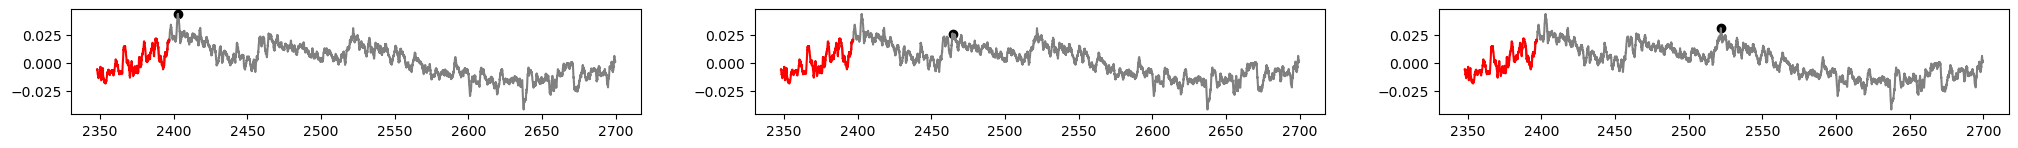

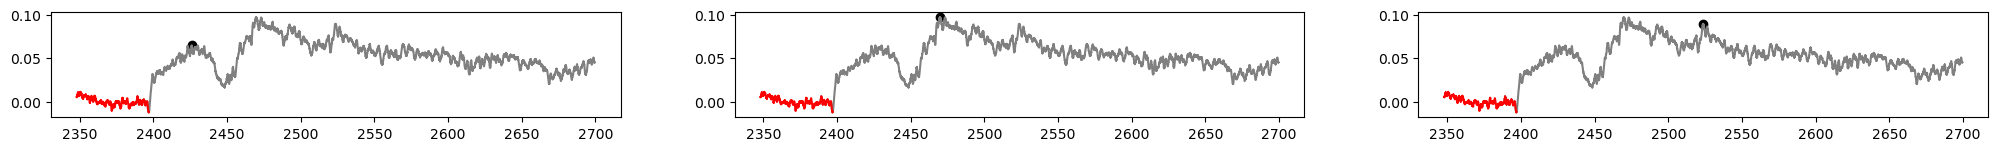

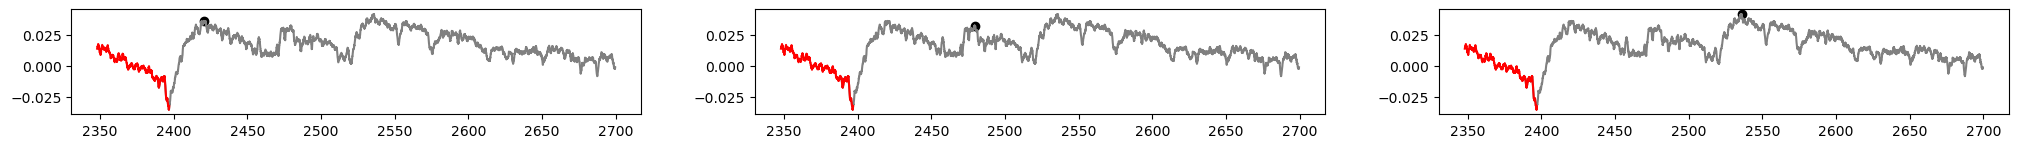

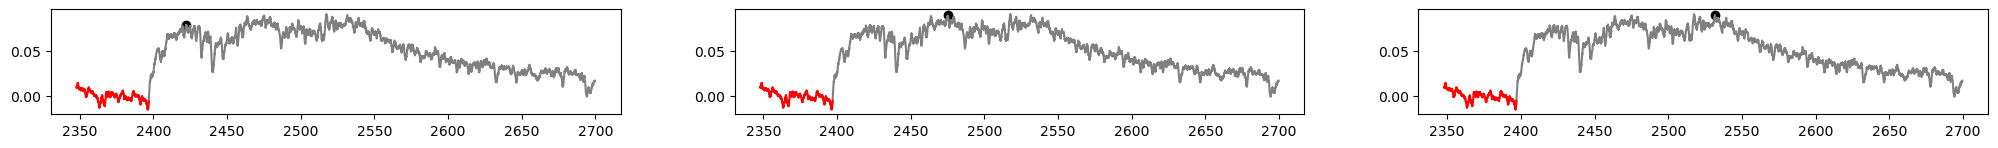

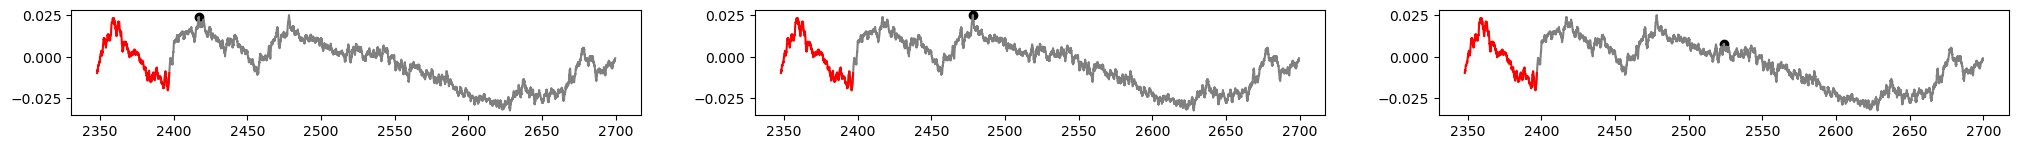

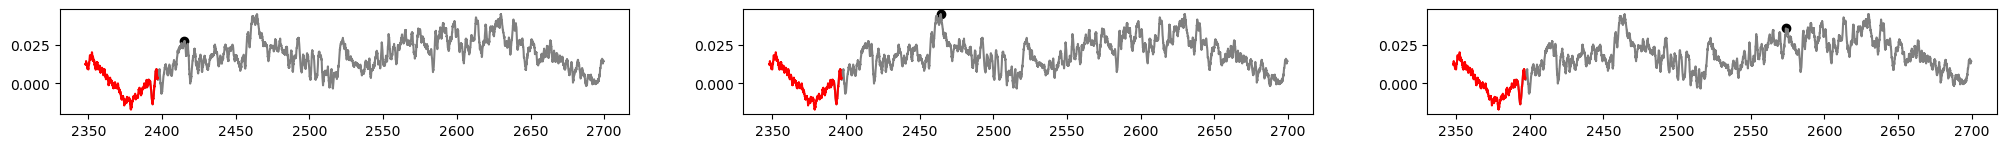

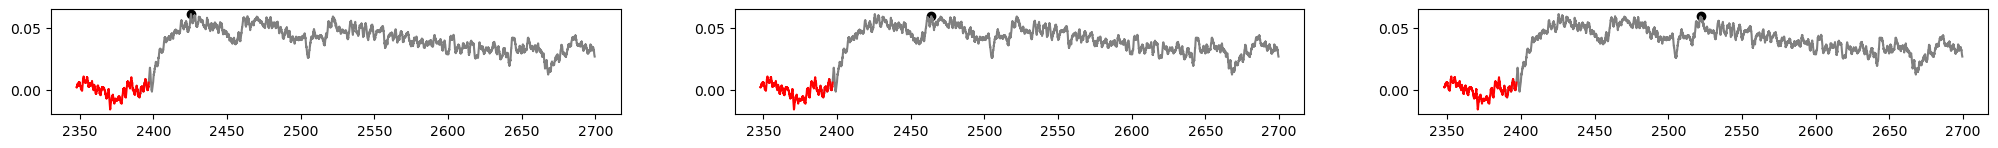

In [153]:
for i,c in enumerate(hM3Dq_CNO_dFF.columns):
    fig = plt.figure(figsize=(25, 3))
    ax1 = fig.add_subplot(2,3,1)
    ax2 = fig.add_subplot(2,3,2)
    ax3 = fig.add_subplot(2,3,3)
    

    ax1.plot(hM3Dq_CNO_dFF.iloc[puff1_start_post:,i].index, hM3Dq_CNO_dFF.iloc[puff1_start_post:,i], color="gray")
    ax1.plot(hM3Dq_CNO_dFF.index[idx_of_the_nearest(time_, 2348):idx_of_the_nearest(time_, 2397)], hM3Dq_CNO_dFF.iloc[idx_of_the_nearest(time_, 2348):idx_of_the_nearest(time_, 2397), i], color="red")
    ax1.scatter(hM3Dq_CNO_puff1_peakInd_pre[i], hM3Dq_CNO_dFF.loc[hM3Dq_CNO_puff1_peakInd_pre[i],c], color="black")
    #plt.ylim(-0.05, 0.15)

    ax2.plot(hM3Dq_CNO_dFF.iloc[puff1_start_post:,i].index, hM3Dq_CNO_dFF.iloc[puff1_start_post:,i], color="gray")
    ax2.plot(hM3Dq_CNO_dFF.index[idx_of_the_nearest(time_, 2348):idx_of_the_nearest(time_, 2397)], hM3Dq_CNO_dFF.iloc[idx_of_the_nearest(time_, 2348):idx_of_the_nearest(time_, 2397), i], color="red")
    ax2.scatter(hM3Dq_CNO_puff2_peakInd_pre[i], hM3Dq_CNO_dFF.loc[hM3Dq_CNO_puff2_peakInd_pre[i],c], color="black")
    #plt.ylim(-0.05, 0.15)
    
    ax3.plot(hM3Dq_CNO_dFF.iloc[puff1_start_post:,i].index, hM3Dq_CNO_dFF.iloc[puff1_start_post:,i], color="gray")
    ax3.plot(hM3Dq_CNO_dFF.index[idx_of_the_nearest(time_, 2348):idx_of_the_nearest(time_, 2397)], hM3Dq_CNO_dFF.iloc[idx_of_the_nearest(time_, 2348):idx_of_the_nearest(time_, 2397), i], color="red")
    ax3.scatter(hM3Dq_CNO_puff3_peakInd_pre[i], hM3Dq_CNO_dFF.loc[hM3Dq_CNO_puff3_peakInd_pre[i],c], color="black")
    #plt.ylim(-0.05, 0.15)

In [154]:
peak_func(hM3Dq_CNO_dFF, hM3Dq_CNO_puff1_peakInd_pre)

{'hM3Dq1_CNO': 0.04361896367128093,
 'hM3Dq2_CNO': 0.06459406937881196,
 'hM3Dq3_CNO': 0.03651513555186314,
 'hM3Dq4_CNO': 0.0787814180481361,
 'hM3Dq5_CNO': 0.023850676943287574,
 'hM3Dq6_CNO': 0.027552294688040657,
 'hM3Dq7_CNO': 0.06094500080548115}

In [155]:
peak_func(hM3Dq_CNO_dFF, hM3Dq_CNO_puff2_peakInd_pre)

{'hM3Dq1_CNO': 0.026158423765573646,
 'hM3Dq2_CNO': 0.09717725163205959,
 'hM3Dq3_CNO': 0.03269015818968879,
 'hM3Dq4_CNO': 0.08923362955111269,
 'hM3Dq5_CNO': 0.024995395223274208,
 'hM3Dq6_CNO': 0.04507765887871629,
 'hM3Dq7_CNO': 0.05920564235792114}

In [156]:
peak_func(hM3Dq_CNO_dFF, hM3Dq_CNO_puff3_peakInd_pre)

{'hM3Dq1_CNO': 0.03097256537762405,
 'hM3Dq2_CNO': 0.08947328347617367,
 'hM3Dq3_CNO': 0.042005928553161986,
 'hM3Dq4_CNO': 0.08974201682749916,
 'hM3Dq5_CNO': 0.007729028452085895,
 'hM3Dq6_CNO': 0.03581816462590148,
 'hM3Dq7_CNO': 0.05903599730864195}

In [190]:
hM3Dq_CNO_dFF.to_excel('hM3Dq_CNO_dFF.xlsx')

### hM3Dq 0.1 CNO

In [159]:
hM3Dq_01CNO_puff1_peakInd_pre = hM3Dq_01CNO_dFF.iloc[puff1_start_post:puff1_end_post,:].idxmax()
hM3Dq_01CNO_puff2_peakInd_pre = hM3Dq_01CNO_dFF.iloc[puff2_start_post:puff2_end_post,:].idxmax()
hM3Dq_01CNO_puff3_peakInd_pre = hM3Dq_01CNO_dFF.iloc[puff3_start_post:puff3_end_post,:].idxmax()

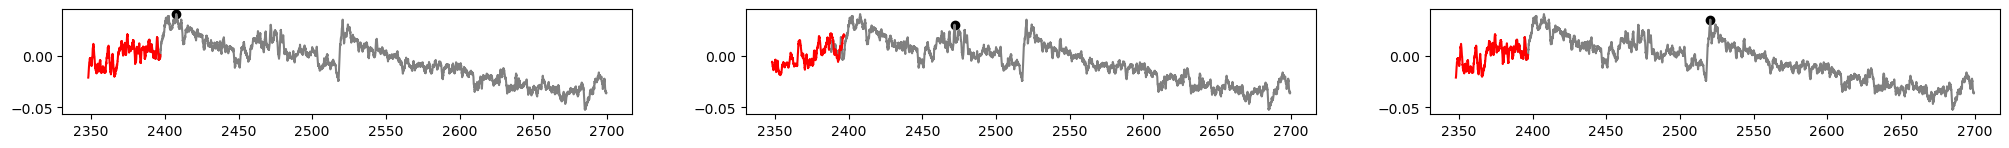

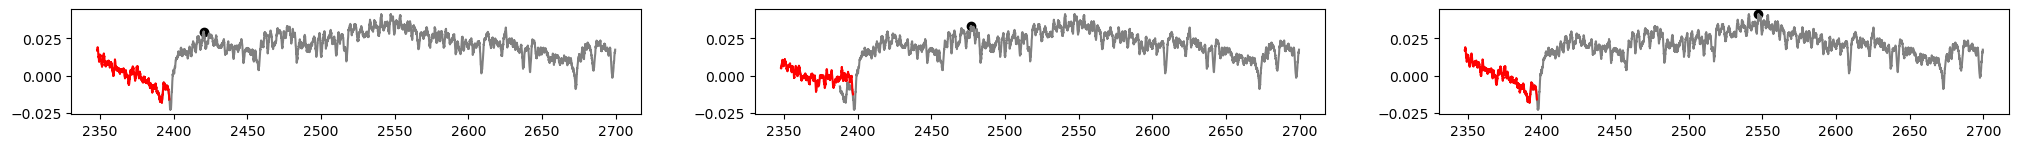

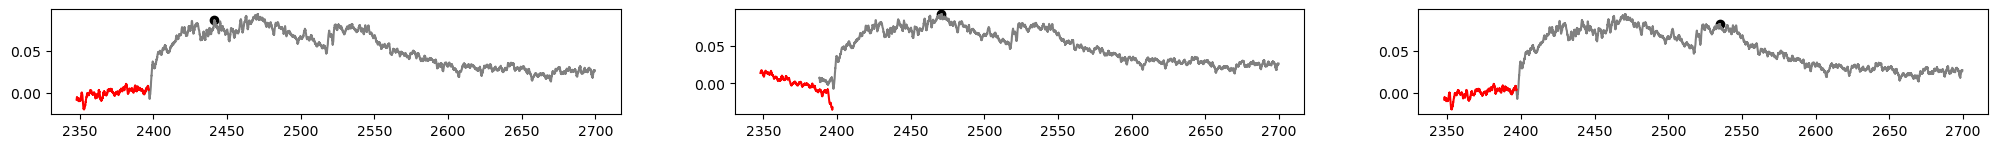

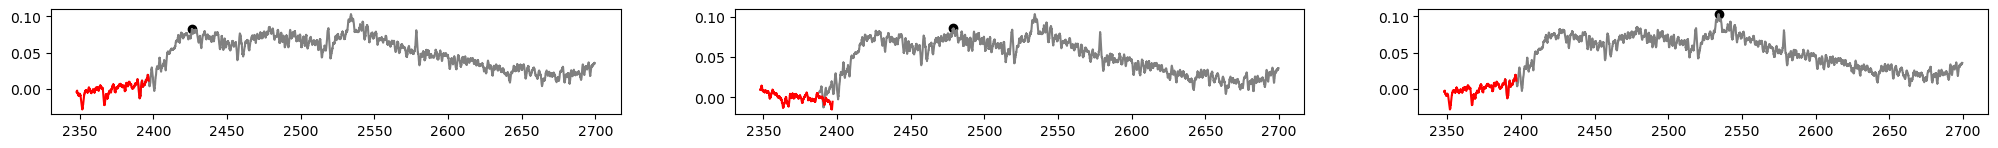

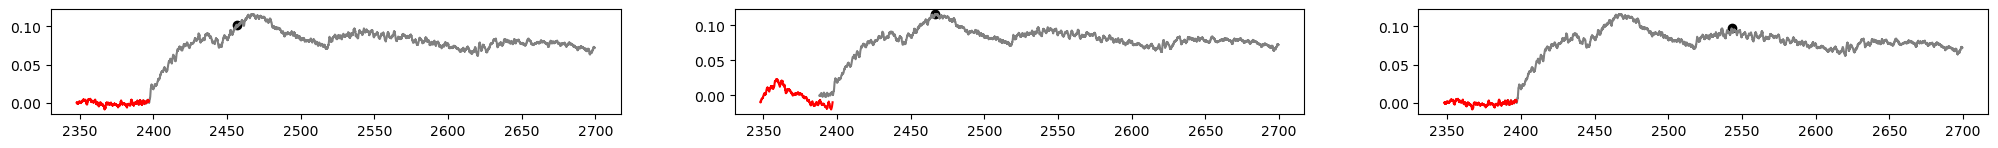

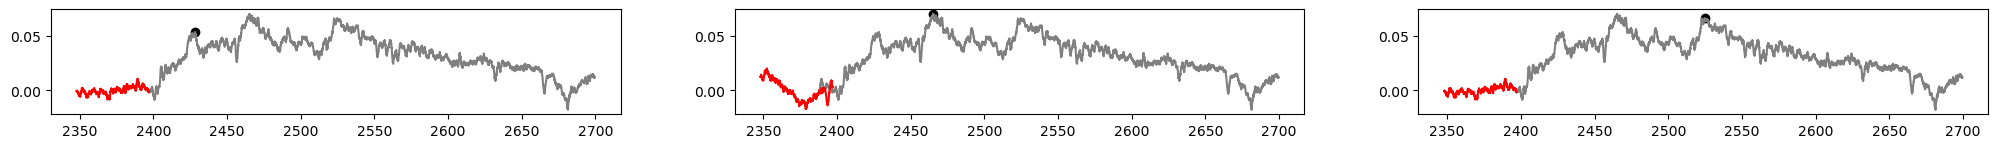

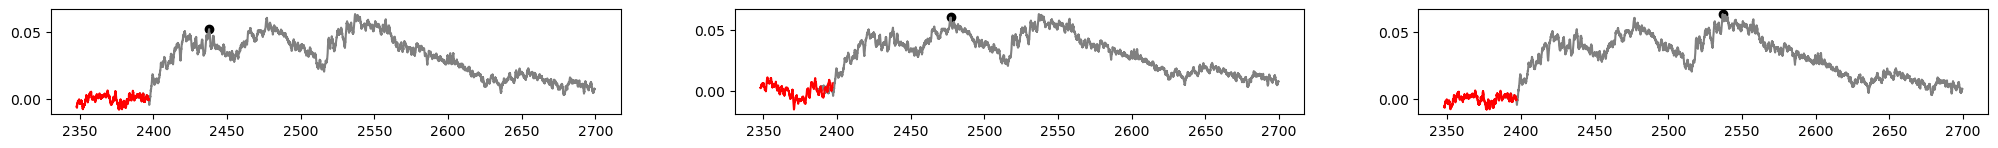

In [160]:
for i,c in enumerate(hM3Dq_01CNO_dFF.columns):
    fig = plt.figure(figsize=(25, 3))
    ax1 = fig.add_subplot(2,3,1)
    ax2 = fig.add_subplot(2,3,2)
    ax3 = fig.add_subplot(2,3,3)
    

    ax1.plot(hM3Dq_01CNO_dFF.iloc[puff1_start_post:,i].index, hM3Dq_01CNO_dFF.iloc[puff1_start_post:,i], color="gray")
    ax1.plot(hM3Dq_01CNO_dFF.index[idx_of_the_nearest(time_, 2348):idx_of_the_nearest(time_, 2397)], hM3Dq_01CNO_dFF.iloc[idx_of_the_nearest(time_, 2348):idx_of_the_nearest(time_, 2397), i], color="red")
    ax1.scatter(hM3Dq_01CNO_puff1_peakInd_pre[i], hM3Dq_01CNO_dFF.loc[hM3Dq_01CNO_puff1_peakInd_pre[i],c], color="black")
    #plt.ylim(-0.05, 0.15)

    ax2.plot(hM3Dq_01CNO_dFF.iloc[puff1_start_post:,i].index, hM3Dq_01CNO_dFF.iloc[puff1_start_post:,i], color="gray")
    ax2.plot(hM3Dq_01CNO_dFF.index[idx_of_the_nearest(time_, 2348):idx_of_the_nearest(time_, 2397)], hM3Dq_CNO_dFF.iloc[idx_of_the_nearest(time_, 2348):idx_of_the_nearest(time_, 2397), i], color="red")
    ax2.scatter(hM3Dq_01CNO_puff2_peakInd_pre[i], hM3Dq_01CNO_dFF.loc[hM3Dq_01CNO_puff2_peakInd_pre[i],c], color="black")
    #plt.ylim(-0.05, 0.15)
    
    ax3.plot(hM3Dq_01CNO_dFF.iloc[puff1_start_post:,i].index, hM3Dq_01CNO_dFF.iloc[puff1_start_post:,i], color="gray")
    ax3.plot(hM3Dq_01CNO_dFF.index[idx_of_the_nearest(time_, 2348):idx_of_the_nearest(time_, 2397)], hM3Dq_01CNO_dFF.iloc[idx_of_the_nearest(time_, 2348):idx_of_the_nearest(time_, 2397), i], color="red")
    ax3.scatter(hM3Dq_01CNO_puff3_peakInd_pre[i], hM3Dq_01CNO_dFF.loc[hM3Dq_01CNO_puff3_peakInd_pre[i],c], color="black")
    #plt.ylim(-0.05, 0.15)

In [161]:
peak_func(hM3Dq_01CNO_dFF, hM3Dq_01CNO_puff1_peakInd_pre)

{'hM3Dq1_01CNO': 0.04044342902871345,
 'hM3Dq2_01CNO': 0.02963740015007077,
 'hM3Dq3_01CNO': 0.0856594564873715,
 'hM3Dq4_01CNO': 0.08266802050009425,
 'hM3Dq5_01CNO': 0.10229691361948545,
 'hM3Dq6_01CNO': 0.05374320201254312,
 'hM3Dq7_01CNO': 0.051880125567791424}

In [162]:
peak_func(hM3Dq_01CNO_dFF, hM3Dq_01CNO_puff2_peakInd_pre)

{'hM3Dq1_01CNO': 0.030084441105855175,
 'hM3Dq2_01CNO': 0.03336675411281398,
 'hM3Dq3_01CNO': 0.09302080234017118,
 'hM3Dq4_01CNO': 0.0857513747678258,
 'hM3Dq5_01CNO': 0.11614257540142414,
 'hM3Dq6_01CNO': 0.07010344548921499,
 'hM3Dq7_01CNO': 0.060261291721522836}

In [163]:
peak_func(hM3Dq_01CNO_dFF, hM3Dq_01CNO_puff3_peakInd_pre)

{'hM3Dq1_01CNO': 0.03502944127007668,
 'hM3Dq2_01CNO': 0.041376740819133895,
 'hM3Dq3_01CNO': 0.08123769295548045,
 'hM3Dq4_01CNO': 0.10334426408779662,
 'hM3Dq5_01CNO': 0.09741457664231323,
 'hM3Dq6_01CNO': 0.06637529233997641,
 'hM3Dq7_01CNO': 0.0630661368836567}

In [191]:
hM3Dq_01CNO_dFF.to_excel('hM3Dq_01CNO_dFF.xlsx')

# Adra1a analysis peak

In [168]:
puff1_start_pre, puff1_end_pre = idx_of_the_nearest(time_, 48), idx_of_the_nearest(time_, 117)+1
puff2_start_pre, puff2_end_pre = idx_of_the_nearest(time_, 118), idx_of_the_nearest(time_, 177)+1
puff3_start_pre, puff3_end_pre = idx_of_the_nearest(time_, 178), idx_of_the_nearest(time_, 237)+1

### Adra1a Control no cre

In [126]:
Cont_saline_puff1_peakInd_pre = Cont_saline_dFF.iloc[puff1_start_pre:puff1_end_pre,:].idxmax()
Cont_saline_puff2_peakInd_pre = Cont_saline_dFF.iloc[puff2_start_pre:puff2_end_pre,:].idxmax()
Cont_saline_puff3_peakInd_pre = Cont_saline_dFF.iloc[puff3_start_pre:puff3_end_pre,:].idxmax()

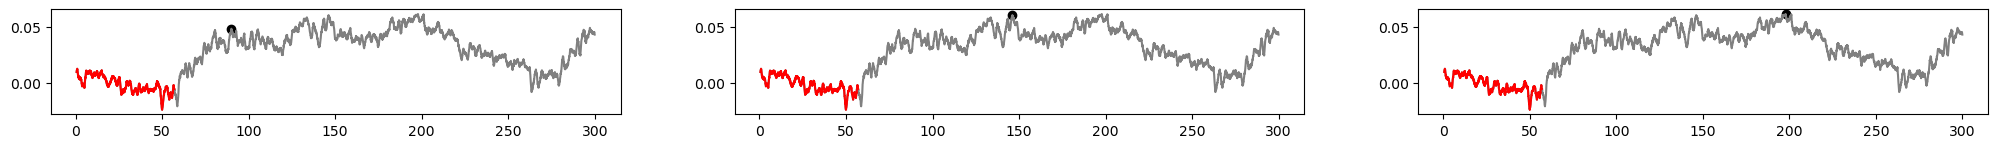

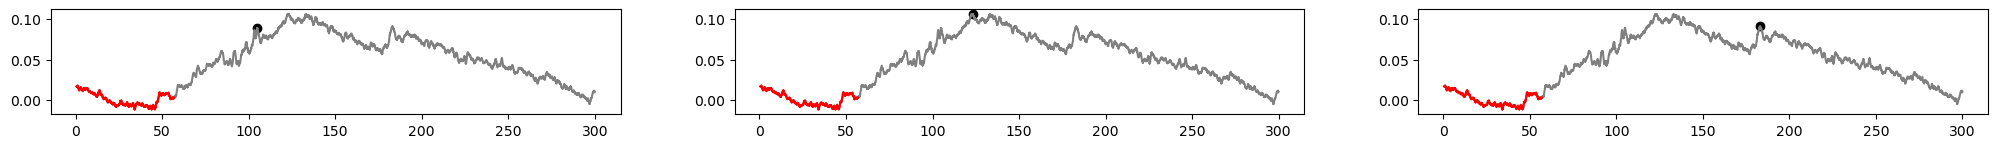

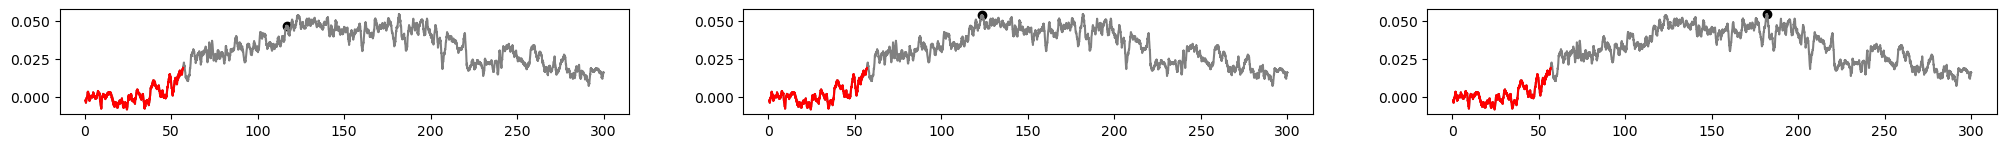

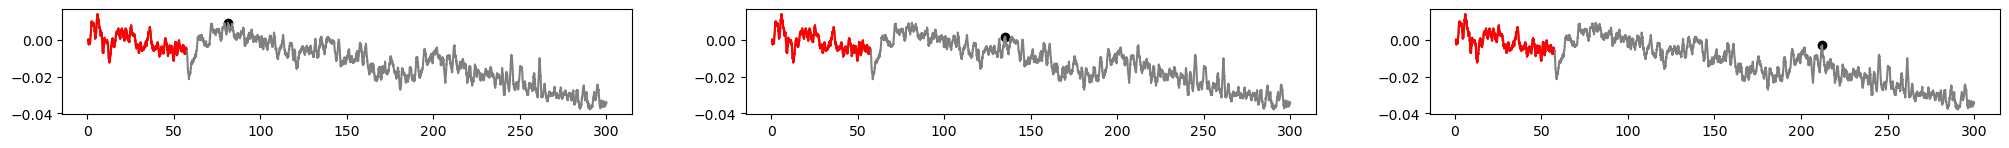

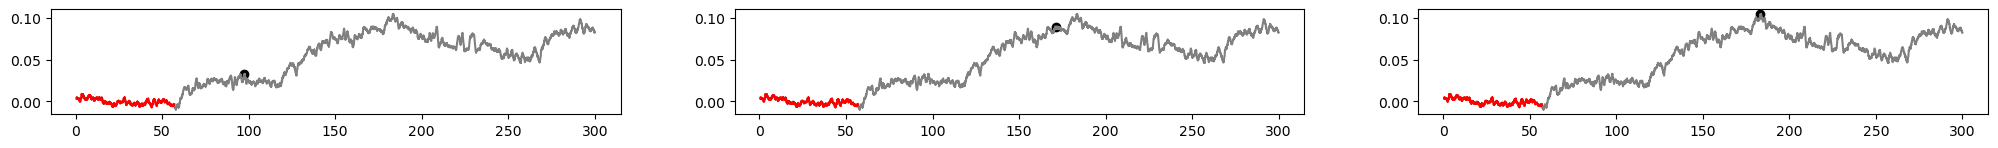

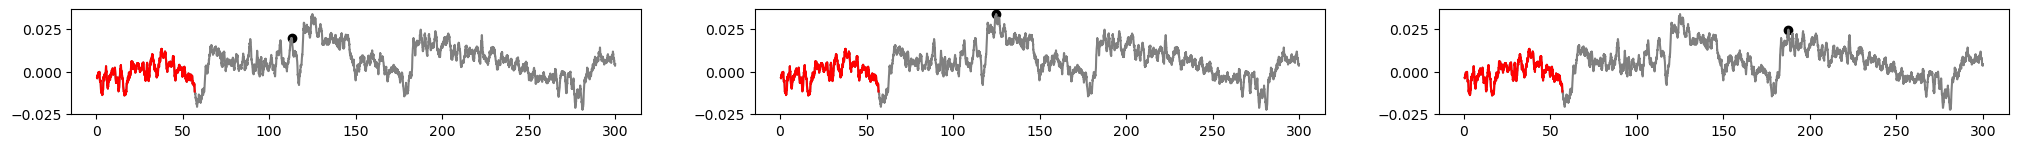

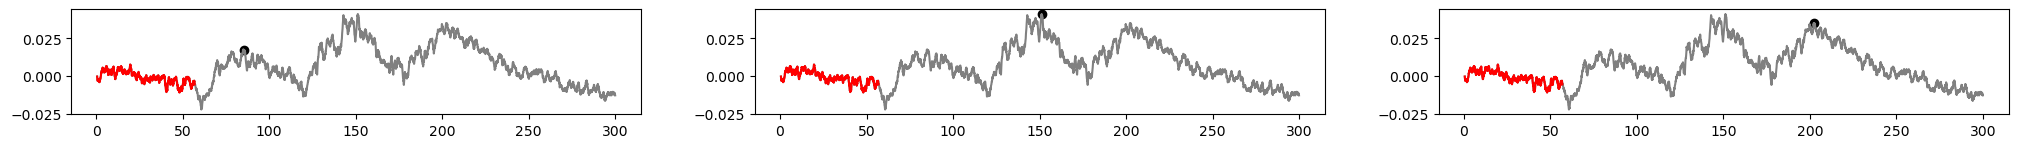

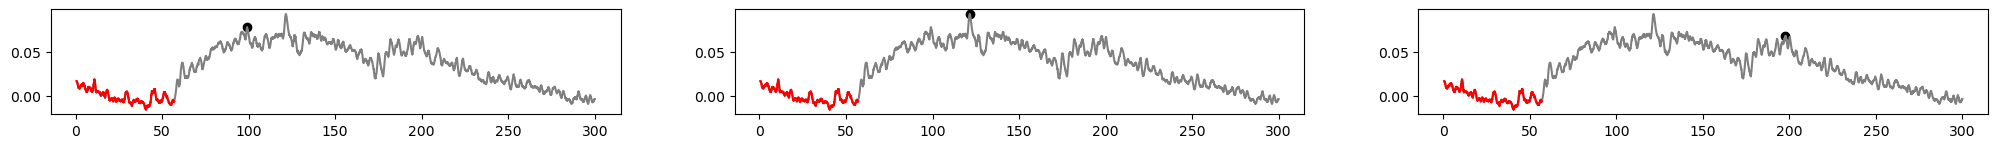

In [169]:
for i,c in enumerate(Cont_saline_dFF.columns):
    fig = plt.figure(figsize=(25, 3))
    ax1 = fig.add_subplot(2,3,1)
    ax2 = fig.add_subplot(2,3,2)
    ax3 = fig.add_subplot(2,3,3)
    

    ax1.plot(Cont_saline_dFF.iloc[:idx_of_the_nearest(time_, 300),i].index, Cont_saline_dFF.iloc[:idx_of_the_nearest(time_, 300),i], color="gray")
    ax1.plot(Cont_saline_dFF.index[idx_of_the_nearest(time_, 0):idx_of_the_nearest(time_, 57)], Cont_saline_dFF.iloc[idx_of_the_nearest(time_, 0):idx_of_the_nearest(time_, 57), i], color="red")
    ax1.scatter(Cont_saline_puff1_peakInd_pre[i], Cont_saline_dFF.loc[Cont_saline_puff1_peakInd_pre[i],c], color="black")
    #plt.ylim(-0.05, 0.15)

    ax2.plot(Cont_saline_dFF.iloc[:idx_of_the_nearest(time_, 300),i].index, Cont_saline_dFF.iloc[:idx_of_the_nearest(time_, 300),i], color="gray")
    ax2.plot(Cont_saline_dFF.index[idx_of_the_nearest(time_, 0):idx_of_the_nearest(time_, 57)], Cont_saline_dFF.iloc[idx_of_the_nearest(time_, 0):idx_of_the_nearest(time_, 57), i], color="red")
    ax2.scatter(Cont_saline_puff2_peakInd_pre[i], Cont_saline_dFF.loc[Cont_saline_puff2_peakInd_pre[i],c], color="black")
    #plt.ylim(-0.05, 0.15)
    
    ax3.plot(Cont_saline_dFF.iloc[:idx_of_the_nearest(time_, 300),i].index, Cont_saline_dFF.iloc[:idx_of_the_nearest(time_, 300),i], color="gray")
    ax3.plot(Cont_saline_dFF.index[idx_of_the_nearest(time_, 0):idx_of_the_nearest(time_, 57)], Cont_saline_dFF.iloc[idx_of_the_nearest(time_, 0):idx_of_the_nearest(time_, 57), i], color="red")
    ax3.scatter(Cont_saline_puff3_peakInd_pre[i], Cont_saline_dFF.loc[Cont_saline_puff3_peakInd_pre[i],c], color="black")
    #plt.ylim(-0.05, 0.15)

In [170]:
peak_func(Cont_saline_dFF, Cont_saline_puff1_peakInd_pre)

{'Cont1_saline': 0.0485223081733116,
 'Cont2_saline': 0.08885919419065813,
 'Cont3_saline': 0.0467888750733183,
 'Cont4_saline': 0.009464224519404985,
 'Cont5_saline': 0.03322714738010901,
 'Cont6_saline': 0.019751831644970297,
 'Cont7_saline': 0.017588237375013804,
 'Cont8_saline': 0.07800205039075592}

In [171]:
peak_func(Cont_saline_dFF, Cont_saline_puff2_peakInd_pre)

{'Cont1_saline': 0.06078470251753443,
 'Cont2_saline': 0.10604068636557751,
 'Cont3_saline': 0.053733321732391426,
 'Cont4_saline': 0.0019038502780652777,
 'Cont5_saline': 0.08993164418218469,
 'Cont6_saline': 0.03388270623880851,
 'Cont7_saline': 0.041084555742854745,
 'Cont8_saline': 0.09282693543119858}

In [172]:
peak_func(Cont_saline_dFF, Cont_saline_puff3_peakInd_pre)

{'Cont1_saline': 0.0617450620723049,
 'Cont2_saline': 0.09104211788092897,
 'Cont3_saline': 0.05435014689324724,
 'Cont4_saline': -0.0027847770163274,
 'Cont5_saline': 0.10494580374915308,
 'Cont6_saline': 0.02469692654547795,
 'Cont7_saline': 0.035122189774089874,
 'Cont8_saline': 0.06806122507504164}

In [192]:
Cont_saline_dFF.to_excel('Cont_saline_dFF.xlsx')

### Adra1a KO with cre

In [173]:
KO_saline_puff1_peakInd_pre = KO_saline_dFF.iloc[puff1_start_pre:puff1_end_pre,:].idxmax()
KO_saline_puff2_peakInd_pre = KO_saline_dFF.iloc[puff2_start_pre:puff2_end_pre,:].idxmax()
KO_saline_puff3_peakInd_pre = KO_saline_dFF.iloc[puff3_start_pre:puff3_end_pre,:].idxmax()

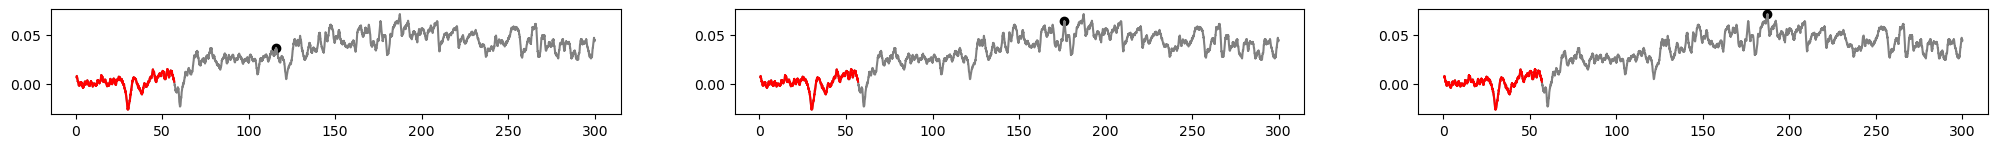

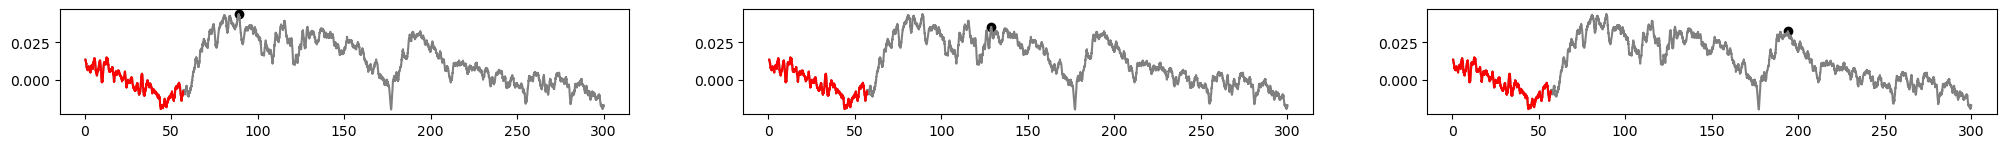

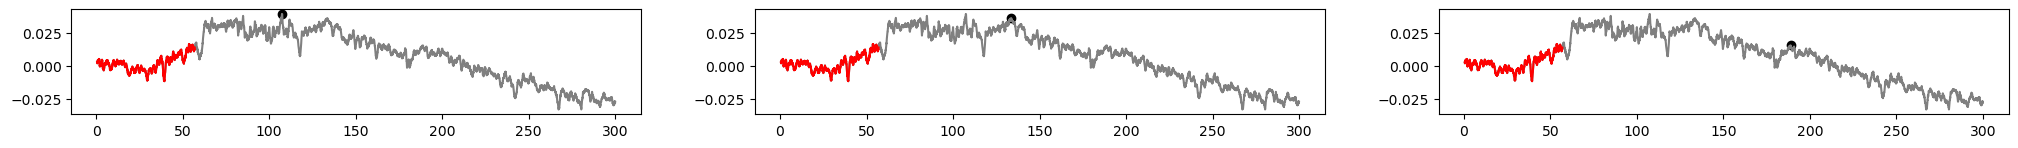

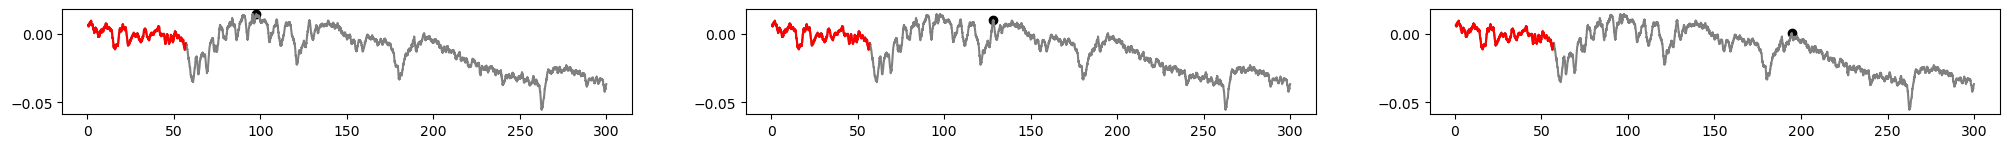

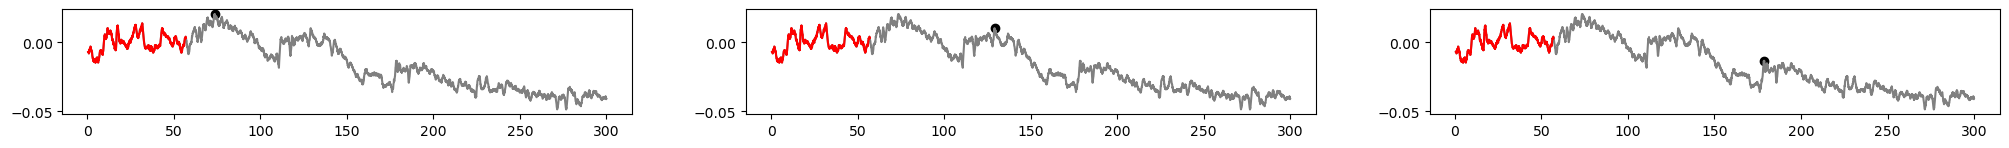

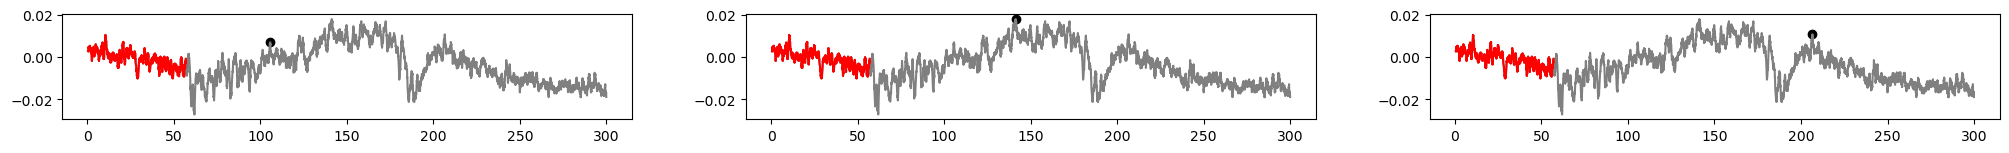

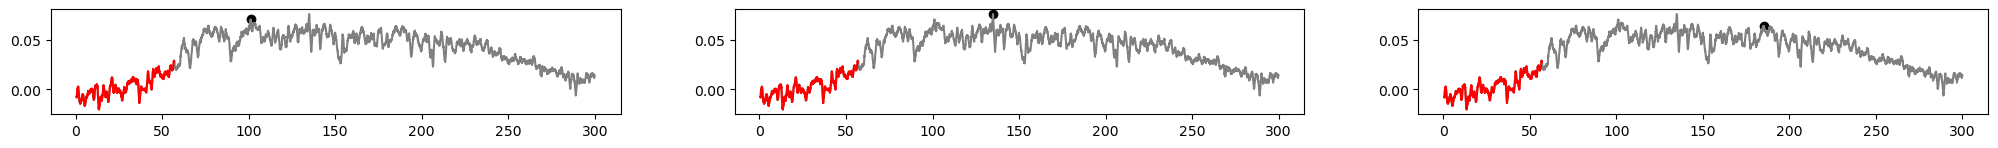

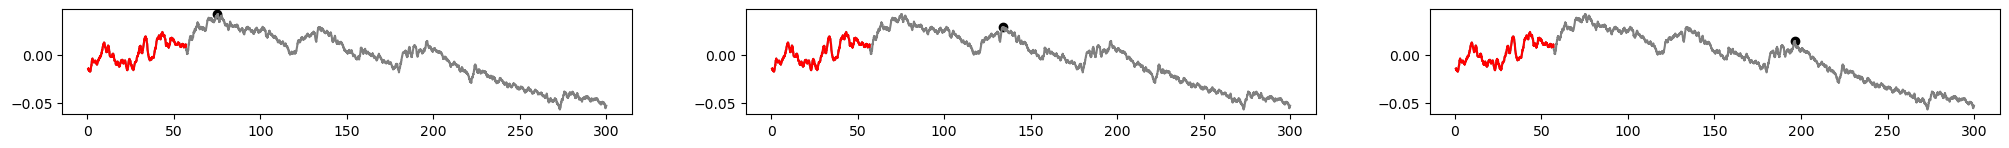

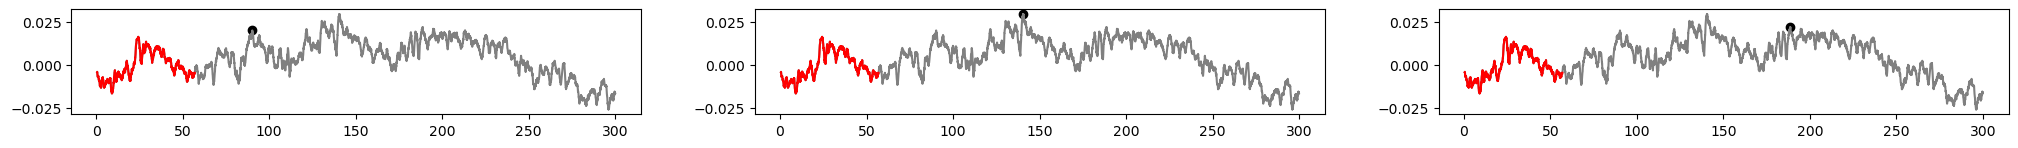

In [174]:
for i,c in enumerate(KO_saline_dFF.columns):
    fig = plt.figure(figsize=(25, 3))
    ax1 = fig.add_subplot(2,3,1)
    ax2 = fig.add_subplot(2,3,2)
    ax3 = fig.add_subplot(2,3,3)
    

    ax1.plot(KO_saline_dFF.iloc[:idx_of_the_nearest(time_, 300),i].index, KO_saline_dFF.iloc[:idx_of_the_nearest(time_, 300),i], color="gray")
    ax1.plot(KO_saline_dFF.index[idx_of_the_nearest(time_, 0):idx_of_the_nearest(time_, 57)], KO_saline_dFF.iloc[idx_of_the_nearest(time_, 0):idx_of_the_nearest(time_, 57), i], color="red")
    ax1.scatter(KO_saline_puff1_peakInd_pre[i], KO_saline_dFF.loc[KO_saline_puff1_peakInd_pre[i],c], color="black")
    #plt.ylim(-0.05, 0.15)

    ax2.plot(KO_saline_dFF.iloc[:idx_of_the_nearest(time_, 300),i].index, KO_saline_dFF.iloc[:idx_of_the_nearest(time_, 300),i], color="gray")
    ax2.plot(KO_saline_dFF.index[idx_of_the_nearest(time_, 0):idx_of_the_nearest(time_, 57)], KO_saline_dFF.iloc[idx_of_the_nearest(time_, 0):idx_of_the_nearest(time_, 57), i], color="red")
    ax2.scatter(KO_saline_puff2_peakInd_pre[i], KO_saline_dFF.loc[KO_saline_puff2_peakInd_pre[i],c], color="black")
    #plt.ylim(-0.05, 0.15)
    
    ax3.plot(KO_saline_dFF.iloc[:idx_of_the_nearest(time_, 300),i].index, KO_saline_dFF.iloc[:idx_of_the_nearest(time_, 300),i], color="gray")
    ax3.plot(KO_saline_dFF.index[idx_of_the_nearest(time_, 0):idx_of_the_nearest(time_, 57)], KO_saline_dFF.iloc[idx_of_the_nearest(time_, 0):idx_of_the_nearest(time_, 57), i], color="red")
    ax3.scatter(KO_saline_puff3_peakInd_pre[i], KO_saline_dFF.loc[KO_saline_puff3_peakInd_pre[i],c], color="black")
    #plt.ylim(-0.05, 0.15)

In [175]:
peak_func(KO_saline_dFF, KO_saline_puff1_peakInd_pre)

{'KO1_saline': 0.03687237235938601,
 'KO2_saline': 0.043950912017028276,
 'KO3_saline': 0.039148615245807594,
 'KO4_saline': 0.014351915792550907,
 'KO5_saline': 0.020656003438471737,
 'KO6_saline': 0.00693891477771813,
 'KO7_saline': 0.07093692376359662,
 'KO8_saline': 0.04198443655747375,
 'KO9_saline': 0.02006855218687531}

In [176]:
peak_func(KO_saline_dFF, KO_saline_puff2_peakInd_pre)

{'KO1_saline': 0.06427731953288407,
 'KO2_saline': 0.03546861652138289,
 'KO3_saline': 0.03588835161915371,
 'KO4_saline': 0.009762593592198554,
 'KO5_saline': 0.01039900450032416,
 'KO6_saline': 0.01794513954285204,
 'KO7_saline': 0.07639987331786657,
 'KO8_saline': 0.028529583366408096,
 'KO9_saline': 0.029602596516922874}

In [177]:
peak_func(KO_saline_dFF, KO_saline_puff3_peakInd_pre)

{'KO1_saline': 0.0715093644207494,
 'KO2_saline': 0.032562666982469235,
 'KO3_saline': 0.01531634886817268,
 'KO4_saline': 0.0005147658394439869,
 'KO5_saline': -0.01324286483949888,
 'KO6_saline': 0.010700739221379152,
 'KO7_saline': 0.06440011703118387,
 'KO8_saline': 0.014097203638949285,
 'KO9_saline': 0.022055393125666622}

In [193]:
KO_saline_dFF.to_excel('KO_saline_dFF.xlsx')